<div style="background: linear-gradient(135deg, #0f2027, #203a43, #2c5364); border-radius: 16px; padding: 50px 40px; text-align: center; font-family: 'Georgia', serif; margin-bottom: 20px;">
    <p style="color: #90caf9; font-size: 14px; letter-spacing: 4px; text-transform: uppercase; margin: 0 0 12px 0;">✈️ Capstone Project — Module 3 | End-to-End Machine Learning</p>
    <h1 style="color: #ffffff; font-size: 42px; font-weight: bold; margin: 0 0 16px 0; line-height: 1.2;">Travel Insurance<br>Claim Prediction</h1>
    <p style="color: #b0bec5; font-size: 18px; margin: 0 0 30px 0;">Binary Classification · Imbalanced Data Handling · Model Interpretability</p>
    <div style="display: flex; justify-content: center; gap: 20px; flex-wrap: wrap;">
        <span style="background: rgba(144,202,249,0.15); color: #90caf9; padding: 8px 20px; border-radius: 20px; font-size: 13px; border: 1px solid rgba(144,202,249,0.3);">📊 Dataset: 39.661 Records (setelah deduplikasi)</span>
        <span style="background: rgba(144,202,249,0.15); color: #90caf9; padding: 8px 20px; border-radius: 20px; font-size: 13px; border: 1px solid rgba(144,202,249,0.3);">🎯 Target: Claim (Yes/No)</span>
        <span style="background: rgba(144,202,249,0.15); color: #90caf9; padding: 8px 20px; border-radius: 20px; font-size: 13px; border: 1px solid rgba(144,202,249,0.3);">🔑 RANDOM_STATE = 42</span>
        <span style="background: rgba(144,202,249,0.15); color: #90caf9; padding: 8px 20px; border-radius: 20px; font-size: 13px; border: 1px solid rgba(144,202,249,0.3);">⚠️ Imbalance: 1,70% vs 98,30%</span>
    </div>
</div>


---
## 📦 Step 1 · Import Libraries

> Semua library yang dibutuhkan untuk proses *end-to-end machine learning* dimuat di sini. `RANDOM_STATE = 42` digunakan secara konsisten di seluruh proyek untuk memastikan reproduktivitas hasil.


In [1]:
!pip install xgboost lightgbm catboost imbalanced-learn --quiet

In [2]:
# ─────────────────────────────────────────────────
# GLOBAL CONSTANT
# ─────────────────────────────────────────────────
RANDOM_STATE = 42

# ─────────────────────────────────────────────────
# DATA MANIPULATION & VISUALIZATION
# ─────────────────────────────────────────────────
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import warnings
import json
import joblib
import shap
from scipy import sparse
import sklearn
from scipy.stats import randint, uniform


warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', '{:.4f}'.format)

# Styling global untuk plot
plt.rcParams.update({
    'figure.facecolor': '#f8f9fa',
    'axes.facecolor':   '#f8f9fa',
    'axes.grid':        True,
    'grid.color':       '#dee2e6',
    'grid.linewidth':   0.6,
    'font.family':      'DejaVu Sans',
    'axes.spines.top':  False,
    'axes.spines.right':False,
})
PALETTE = ['#1565c0', '#e53935']   # biru = No, merah = Yes

# ─────────────────────────────────────────────────
# PREPROCESSING
# ─────────────────────────────────────────────────
from sklearn.preprocessing import (
    StandardScaler, OrdinalEncoder, LabelEncoder
)
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

# ─────────────────────────────────────────────────
# MODEL SELECTION & SPLITTING
# ─────────────────────────────────────────────────
from sklearn.model_selection import (
    train_test_split, StratifiedKFold,
    cross_val_score, RandomizedSearchCV
)

# ─────────────────────────────────────────────────
# CLASSIFICATION MODELS
# ─────────────────────────────────────────────────
from sklearn.linear_model    import LogisticRegression
from sklearn.neighbors       import KNeighborsClassifier
from sklearn.tree            import DecisionTreeClassifier
from sklearn.ensemble        import (
    RandomForestClassifier, GradientBoostingClassifier,
    AdaBoostClassifier
)
from xgboost  import XGBClassifier
from lightgbm import LGBMClassifier
from catboost import CatBoostClassifier

# ─────────────────────────────────────────────────
# IMBALANCED-LEARN (RESAMPLING)
# ─────────────────────────────────────────────────
from imblearn.over_sampling  import RandomOverSampler, SMOTE
from imblearn.under_sampling import RandomUnderSampler, NearMiss
from imblearn.combine        import SMOTETomek
from imblearn.pipeline       import Pipeline as ImbPipeline

# ─────────────────────────────────────────────────
# EVALUATION METRICS
# ─────────────────────────────────────────────────
from sklearn.metrics import (
    classification_report, confusion_matrix,
    ConfusionMatrixDisplay,
    roc_auc_score, average_precision_score,
    recall_score, precision_score, f1_score,
    precision_recall_curve, roc_curve
)

# ─────────────────────────────────────────────────
# MODEL SAVING
# ─────────────────────────────────────────────────
import joblib
import time

print("✅ Semua library berhasil diimport!")
print(f"   RANDOM_STATE = {RANDOM_STATE}")


✅ Semua library berhasil diimport!
   RANDOM_STATE = 42


---
## 📂 Step 2 · Load Dataset

> Dataset dimuat dari file CSV. Pemeriksaan awal dilakukan untuk memastikan data berhasil dimuat dengan benar sebelum masuk ke tahap analisis lebih lanjut.


In [3]:
# Load dataset
df = pd.read_csv('data_travel_insurance.csv')

print("=" * 60)
print("  INFORMASI DASAR DATASET")
print("=" * 60)
print(f"  Jumlah Baris    : {df.shape[0]:,}")
print(f"  Jumlah Kolom    : {df.shape[1]}")
print(f"  Total Data Poin : {df.size:,}")
print("=" * 60)

df.head(10)


  INFORMASI DASAR DATASET
  Jumlah Baris    : 44,328
  Jumlah Kolom    : 11
  Total Data Poin : 487,608


,Agency,Agency Type,Distribution Channel,Product Name,Gender,Duration,Destination,Net Sales,Commision (in value),Age,Claim
0,C2B,Airlines,Online,Annual Silver Plan,F,365,SINGAPORE,216.0000,54.0000,57,No
1,EPX,Travel Agency,Online,Cancellation Plan,NaN,4,MALAYSIA,10.0000,0.0000,33,No
2,JZI,Airlines,Online,Basic Plan,M,19,INDIA,22.0000,7.7000,26,No
3,EPX,Travel Agency,Online,2 way Comprehensive Plan,NaN,20,UNITED STATES,112.0000,0.0000,59,No
4,C2B,Airlines,Online,Bronze Plan,M,8,SINGAPORE,16.0000,4.0000,28,No
5,EPX,Travel Agency,Online,Cancellation Plan,NaN,2,SINGAPORE,10.0000,0.0000,36,No
6,EPX,Travel Agency,Online,1 way Comprehensive Plan,NaN,25,"KOREA, REPUBLIC OF",50.0000,0.0000,36,No
7,EPX,Travel Agency,Online,Cancellation Plan,NaN,90,SINGAPORE,78.0000,0.0000,22,No
8,JZI,Airlines,Online,Basic Plan,M,4,THAILAND,22.0000,7.7000,39,No
9,EPX,Travel Agency,Online,Cancellation Plan,NaN,24,GERMANY,80.0000,0.0000,36,No


In [4]:
# Informasi tipe data
print("\n📋 INFO TIPE DATA:")
df.info()



📋 INFO TIPE DATA:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 44328 entries, 0 to 44327
Data columns (total 11 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Agency                44328 non-null  object 
 1   Agency Type           44328 non-null  object 
 2   Distribution Channel  44328 non-null  object 
 3   Product Name          44328 non-null  object 
 4   Gender                12681 non-null  object 
 5   Duration              44328 non-null  int64  
 6   Destination           44328 non-null  object 
 7   Net Sales             44328 non-null  float64
 8   Commision (in value)  44328 non-null  float64
 9   Age                   44328 non-null  int64  
 10  Claim                 44328 non-null  object 
dtypes: float64(2), int64(2), object(7)
memory usage: 3.7+ MB


# 3. Introduction

## 3.1 Business Context

Travel insurance merupakan produk asuransi yang memberikan perlindungan selama perjalanan, seperti keterlambatan penerbangan, kehilangan bagasi, pembatalan perjalanan, kecelakaan, atau kebutuhan medis.

Dalam bisnis travel insurance, klaim perlu diprediksi karena dapat berdampak pada biaya perusahaan, profitabilitas, dan pencadangan dana klaim. Oleh karena itu, perusahaan membutuhkan pendekatan berbasis data untuk mengidentifikasi pemegang polis yang memiliki risiko klaim lebih tinggi.

---

## 3.2 Problem Statement

Permasalahan utama dalam project ini adalah perusahaan belum memiliki sistem prediksi yang dapat mengidentifikasi pemegang polis dengan risiko klaim secara akurat dan efisien.

Dataset memiliki kondisi target yang sangat tidak seimbang, karena jumlah nasabah yang mengajukan klaim jauh lebih sedikit dibandingkan yang tidak klaim. Jika hanya menggunakan accuracy, model dapat terlihat bagus meskipun gagal mendeteksi nasabah yang benar-benar melakukan klaim.

---

## 3.3 Business Goals

Tujuan project ini adalah membangun model klasifikasi untuk memprediksi kemungkinan pemegang polis mengajukan klaim.

Model ini diharapkan dapat membantu perusahaan untuk:

1. Mengidentifikasi nasabah dengan risiko klaim tinggi.
2. Membantu proses underwriting dan evaluasi risiko.
3. Mendukung strategi pricing berbasis risiko.
4. Membantu pencadangan dana klaim.
5. Mengurangi risiko klaim yang tidak terantisipasi.

Model ini tidak digunakan untuk menolak klaim, tetapi sebagai alat bantu prediksi risiko dan pengambilan keputusan bisnis.

---

## 3.4 Analytical Approach

Project ini menggunakan pendekatan supervised machine learning dengan metode binary classification.

Target yang diprediksi adalah kolom `Claim`, yaitu:

- `Yes`: pemegang polis mengajukan klaim.
- `No`: pemegang polis tidak mengajukan klaim.

Model akan mempelajari pola dari data historis seperti agency, product name, destination, duration, age, net sales, dan commission untuk memprediksi kemungkinan klaim.

Selain menghasilkan prediksi `Claim` atau `No Claim`, model juga dapat menghasilkan risk score untuk membantu perusahaan menentukan prioritas evaluasi risiko.

---

## 3.5 Recommended Stakeholder

Stakeholder utama yang paling cocok menggunakan hasil model ini adalah:

### 1. Tim Underwriting / Risk Assessment

Tim underwriting dapat menggunakan model untuk menilai risiko calon pemegang polis sebelum polis diterbitkan. Model membantu mengidentifikasi nasabah yang memiliki kemungkinan klaim lebih tinggi dan menentukan apakah perlu evaluasi tambahan.

### 2. Tim Risk Management / Actuarial Pricing

Tim risk management atau actuarial pricing dapat menggunakan hasil model untuk memahami profil risiko nasabah, membantu strategi penetapan premi, dan menyiapkan pencadangan dana klaim dengan lebih baik.

---

## 3.6 Business Explanation of False Positive and False Negative

Dalam model klasifikasi travel insurance, terdapat dua jenis kesalahan prediksi yang penting:

### False Positive

False Positive terjadi ketika model memprediksi nasabah akan klaim, padahal sebenarnya tidak klaim.

Dampaknya:

- Perusahaan melakukan evaluasi tambahan yang tidak diperlukan.
- Biaya operasional meningkat.
- Tim underwriting menjadi kurang efisien.
- Customer experience dapat terganggu jika perlakuan risiko terlalu ketat.

### False Negative

False Negative terjadi ketika model memprediksi nasabah tidak akan klaim, padahal sebenarnya mengajukan klaim.

Dampaknya:

- Risiko klaim tidak terdeteksi sejak awal.
- Perusahaan gagal melakukan antisipasi risiko.
- Pencadangan dana klaim kurang optimal.
- Potensi kerugian perusahaan menjadi lebih besar.

Dalam konteks travel insurance, False Negative lebih berisiko dibandingkan False Positive. Oleh karena itu, model perlu memprioritaskan nilai Recall yang tinggi agar lebih banyak klaim aktual dapat terdeteksi.

---

## 3.7 Metric Evaluation

Karena data klaim sangat tidak seimbang, accuracy tidak cocok digunakan sebagai metrik utama. Model yang selalu memprediksi `No Claim` bisa memiliki accuracy tinggi, tetapi tidak berguna karena gagal mendeteksi klaim.

Metrik evaluasi yang digunakan adalah:

| Metric | Fungsi |
|---|---|
| Recall | Mengukur kemampuan model mendeteksi nasabah yang benar-benar klaim |
| Precision | Mengukur ketepatan prediksi klaim |
| F1-Score | Mengukur keseimbangan antara precision dan recall |
| PR AUC | Cocok untuk dataset tidak seimbang |
| Confusion Matrix | Melihat jumlah False Positive dan False Negative |
| Cost Analysis | Mengukur dampak biaya dari kesalahan prediksi |

Model terbaik dipilih berdasarkan kombinasi recall tinggi, False Negative rendah, False Positive yang masih dapat diterima, dan total cost paling efisien.

---

## 3.8 Business Impact

Model klasifikasi ini diharapkan dapat membantu perusahaan dalam mengambil keputusan berbasis data.

Manfaat bisnis dari model ini adalah:

1. Mengetahui profil nasabah dengan risiko klaim tinggi.
2. Membantu tim underwriting dalam evaluasi risiko.
3. Mendukung strategi pricing dan pencadangan dana klaim.
4. Mengurangi risiko klaim yang tidak terantisipasi.
5. Meningkatkan efisiensi proses bisnis.

Dengan demikian, model machine learning dapat digunakan sebagai alat bantu untuk meningkatkan manajemen risiko pada produk travel insurance.

---
## 🔍 Step 4 · Data Understanding & EDA

### 4a. Data Dictionary
| Kolom | Tipe | Deskripsi |
|---|---|---|
| `Agency` | Kategorikal | Nama agen asuransi (16 nilai unik) |
| `Agency Type` | Kategorikal | Airlines / Travel Agency |
| `Distribution Channel` | Kategorikal | Online / Offline |
| `Product Name` | Kategorikal | Nama produk asuransi (26 nilai unik) |
| `Gender` | Kategorikal | F / M — **~69,76% MISSING** |
| `Duration` | Numerik | Durasi perjalanan dalam hari |
| `Destination` | Kategorikal | Negara tujuan perjalanan (138 nilai unik) |
| `Net Sales` | Numerik | Total penjualan polis (nilai premi) |
| `Commision (in value)` | Numerik | Komisi agen dalam nilai absolut |
| `Age` | Numerik | Usia pemegang polis |
| `Claim` ✅ | **Target** | Yes / No — apakah mengajukan klaim |


In [5]:
# ─── 4b-i. DUPLICATE DETECTION ─────────────────────
print("=" * 55)
print("  4b-i | DUPLICATE DETECTION")
print("=" * 55)

n_dup = df.duplicated().sum()
print(f"  Jumlah baris duplikat : {n_dup:,} ({n_dup/len(df)*100:.2f}%)")

# Drop duplicates
df_clean = df.drop_duplicates().reset_index(drop=True)
print(f"  Shape setelah drop dup: {df_clean.shape}")
print(f"  Baris terhapus        : {len(df) - len(df_clean):,}")
print()
print("💡 Insight: Terdapat baris duplikat yang perlu dihapus untuk menjaga")
print("   kualitas data dan menghindari bias pada proses pemodelan.")


  4b-i | DUPLICATE DETECTION
  Jumlah baris duplikat : 4,667 (10.53%)
  Shape setelah drop dup: (39661, 11)
  Baris terhapus        : 4,667

💡 Insight: Terdapat baris duplikat yang perlu dihapus untuk menjaga
   kualitas data dan menghindari bias pada proses pemodelan.


In [6]:
# ─── MISSING VALUES ─────────────────────────────────
print("=" * 60)
print("  MISSING VALUES SUMMARY")
print("=" * 60)

missing     = df_clean.isnull().sum()
missing_pct = (missing / len(df_clean) * 100).round(2)
missing_df  = pd.DataFrame({
    'Missing Count': missing,
    'Missing (%)': missing_pct
}).sort_values('Missing (%)', ascending=False)

print(missing_df.to_string())
print()

gender_missing     = df_clean['Gender'].isnull().sum()
gender_missing_pct = gender_missing / len(df_clean) * 100
print(f"💡 Insight: Kolom 'Gender' memiliki {gender_missing:,} data missing ({gender_missing_pct:.2f}%).")
print("   → Karena lebih dari 50% data missing, pengisian dengan modus tidak ideal.")
print("   → Kolom Gender akan diisi dengan kategori 'Unknown' agar informasi distribusi")
print("     tetap terjaga dan tidak memberikan asumsi yang menyesatkan.")


  MISSING VALUES SUMMARY
                      Missing Count  Missing (%)
Gender                        27667      69.7600
Agency                            0       0.0000
Agency Type                       0       0.0000
Distribution Channel              0       0.0000
Product Name                      0       0.0000
Duration                          0       0.0000
Destination                       0       0.0000
Net Sales                         0       0.0000
Commision (in value)              0       0.0000
Age                               0       0.0000
Claim                             0       0.0000

💡 Insight: Kolom 'Gender' memiliki 27,667 data missing (69.76%).
   → Karena lebih dari 50% data missing, pengisian dengan modus tidak ideal.
   → Kolom Gender akan diisi dengan kategori 'Unknown' agar informasi distribusi
     tetap terjaga dan tidak memberikan asumsi yang menyesatkan.


In [7]:
# ─── 4b-ii. OUTLIER DETECTION ─────────────────────
print("=" * 60)
print("  4b-ii | OUTLIER DETECTION (IQR Method)")
print("=" * 60)

num_cols = ['Duration', 'Net Sales', 'Commision (in value)', 'Age']

for col in num_cols:
    Q1  = df_clean[col].quantile(0.25)
    Q3  = df_clean[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    n_out = ((df_clean[col] < lower) | (df_clean[col] > upper)).sum()
    print(f"  {col:<25} | Q1={Q1:.1f} Q3={Q3:.1f} | Batas: [{lower:.1f}, {upper:.1f}] | Outlier: {n_out:,} ({n_out/len(df_clean)*100:.2f}%)")

print()
print("💡 Insight:")
print("   - Duration  : Ada nilai negatif (tidak valid) → akan di-clip ke 0")
print("   - Age       : Nilai 0 dan >100 tidak realistis → akan di-clip ke rentang [18, 100]")
print("   - Net Sales : Nilai negatif kemungkinan refund/koreksi → dibiarkan, informasi kontekstual")
print("   - Komisi    : Outlier ekstrem mengikuti distribusi Net Sales, konsisten secara bisnis")


  4b-ii | OUTLIER DETECTION (IQR Method)
  Duration                  | Q1=11.0 Q3=57.0 | Batas: [-58.0, 126.0] | Outlier: 3,495 (8.81%)
  Net Sales                 | Q1=19.0 Q3=50.0 | Batas: [-27.5, 96.5] | Outlier: 3,597 (9.07%)
  Commision (in value)      | Q1=0.0 Q3=11.9 | Batas: [-17.8, 29.7] | Outlier: 4,084 (10.30%)
  Age                       | Q1=34.0 Q3=45.0 | Batas: [17.5, 61.5] | Outlier: 2,303 (5.81%)

💡 Insight:
   - Duration  : Ada nilai negatif (tidak valid) → akan di-clip ke 0
   - Age       : Nilai 0 dan >100 tidak realistis → akan di-clip ke rentang [18, 100]
   - Net Sales : Nilai negatif kemungkinan refund/koreksi → dibiarkan, informasi kontekstual
   - Komisi    : Outlier ekstrem mengikuti distribusi Net Sales, konsisten secara bisnis


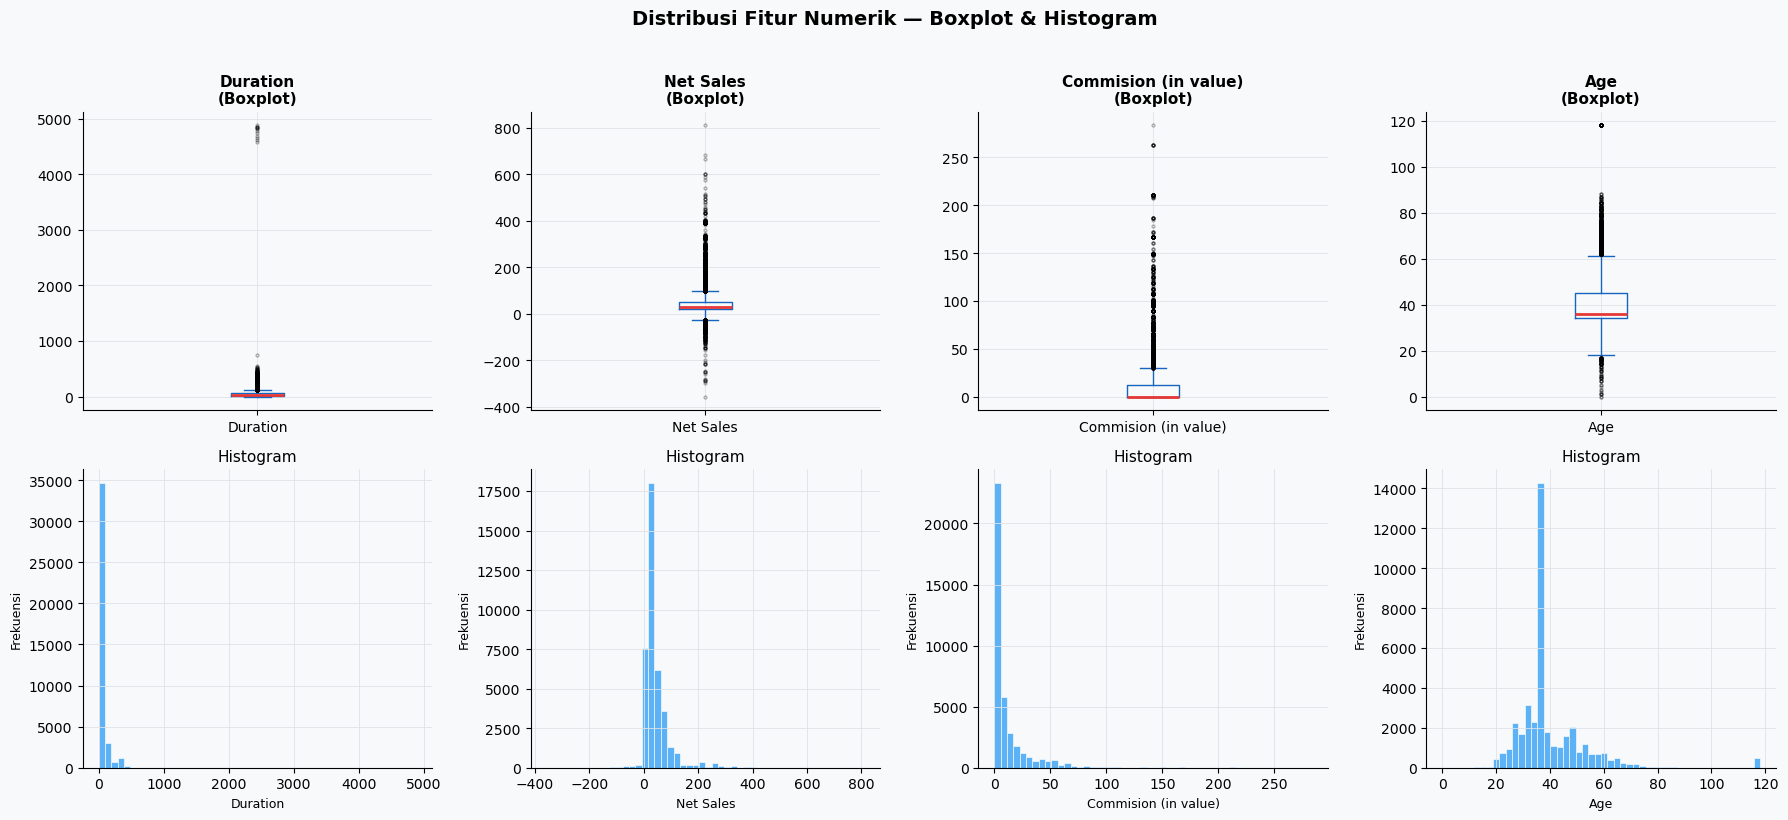

In [8]:
# ─── VISUALISASI DISTRIBUSI NUMERIK ────────────────
fig, axes = plt.subplots(2, 4, figsize=(18, 8))
fig.suptitle('Distribusi Fitur Numerik — Boxplot & Histogram',
             fontsize=14, fontweight='bold', y=1.02)

colors = ['#1565c0', '#42a5f5']

for i, col in enumerate(num_cols):
    # Boxplot
    ax_box = axes[0, i]
    df_clean.boxplot(column=col, ax=ax_box,
                     boxprops=dict(color=colors[0]),
                     medianprops=dict(color='#e53935', linewidth=2),
                     whiskerprops=dict(color=colors[0]),
                     capprops=dict(color=colors[0]),
                     flierprops=dict(marker='o', alpha=0.3, markersize=2, color='#e53935'))
    ax_box.set_title(f'{col}\n(Boxplot)', fontsize=11, fontweight='bold')
    ax_box.set_xlabel('')

    # Histogram
    ax_hist = axes[1, i]
    ax_hist.hist(df_clean[col].dropna(), bins=50, color=colors[1], edgecolor='white', linewidth=0.5, alpha=0.85)
    ax_hist.set_title(f'Histogram', fontsize=11)
    ax_hist.set_xlabel(col, fontsize=9)
    ax_hist.set_ylabel('Frekuensi', fontsize=9)

plt.tight_layout()
plt.show()


  4b-iii | IMBALANCE DETECTION
  Kelas 'No'  (0) : 38,986 record (98.30%)
  Kelas 'Yes' (1) : 675 record (1.70%)
  Rasio Imbalance : 1 : 57

  ⚠️  Data SANGAT imbalanced (kelas Yes < 2% dari total data)
  → Karena data sangat imbalanced, diperlukan strategi penanganan imbalance,
  →   seperti resampling, class weighting, scale_pos_weight, threshold tuning, atau cost-sensitive learning.
  → Metrik utama BUKAN accuracy, melainkan Recall, PR AUC, dan F1-score


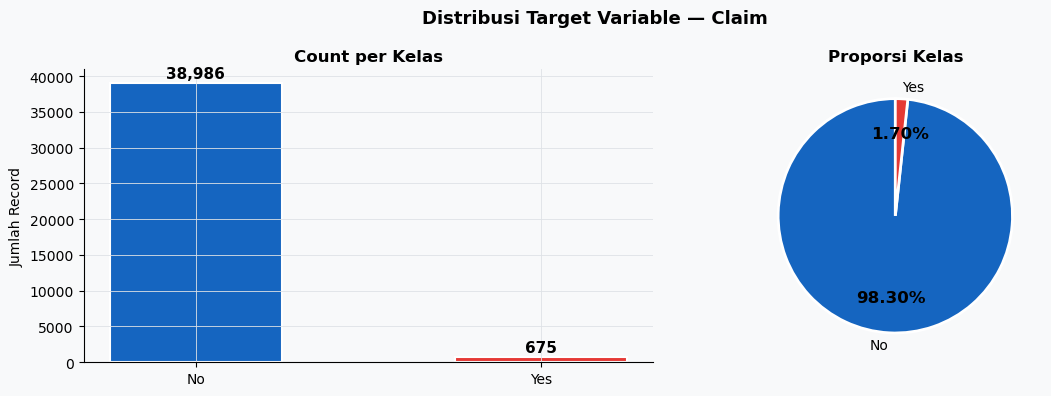

In [9]:
# ─── 4b-iii. IMBALANCE DETECTION ──────────────────
print("=" * 55)
print("  4b-iii | IMBALANCE DETECTION")
print("=" * 55)

claim_counts = df_clean['Claim'].value_counts()
claim_pct    = df_clean['Claim'].value_counts(normalize=True) * 100

print(f"  Kelas 'No'  (0) : {claim_counts['No']:,} record ({claim_pct['No']:.2f}%)")
print(f"  Kelas 'Yes' (1) : {claim_counts['Yes']:,} record ({claim_pct['Yes']:.2f}%)")
print(f"  Rasio Imbalance : 1 : {claim_counts['No']//claim_counts['Yes']}")
print()
print("  ⚠️  Data SANGAT imbalanced (kelas Yes < 2% dari total data)")
print("  → Karena data sangat imbalanced, diperlukan strategi penanganan imbalance,")
print("  →   seperti resampling, class weighting, scale_pos_weight, threshold tuning, atau cost-sensitive learning.")
print("  → Metrik utama BUKAN accuracy, melainkan Recall, PR AUC, dan F1-score")

# Plot distribusi target
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
fig.suptitle('Distribusi Target Variable — Claim', fontsize=13, fontweight='bold')

bars = axes[0].bar(claim_counts.index, claim_counts.values, color=PALETTE, edgecolor='white', linewidth=1.5, width=0.5)
axes[0].set_title('Count per Kelas', fontweight='bold')
axes[0].set_ylabel('Jumlah Record')
for bar, val in zip(bars, claim_counts.values):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 300,
                 f'{val:,}', ha='center', va='bottom', fontweight='bold', fontsize=11)

wedges, texts, autotexts = axes[1].pie(
    claim_counts.values,
    labels=claim_counts.index,
    colors=PALETTE,
    autopct='%1.2f%%',
    startangle=90,
    pctdistance=0.7,
    wedgeprops={'linewidth': 2, 'edgecolor': 'white'}
)
for at in autotexts:
    at.set_fontsize(12)
    at.set_fontweight('bold')
axes[1].set_title('Proporsi Kelas', fontweight='bold')

plt.tight_layout()
plt.show()


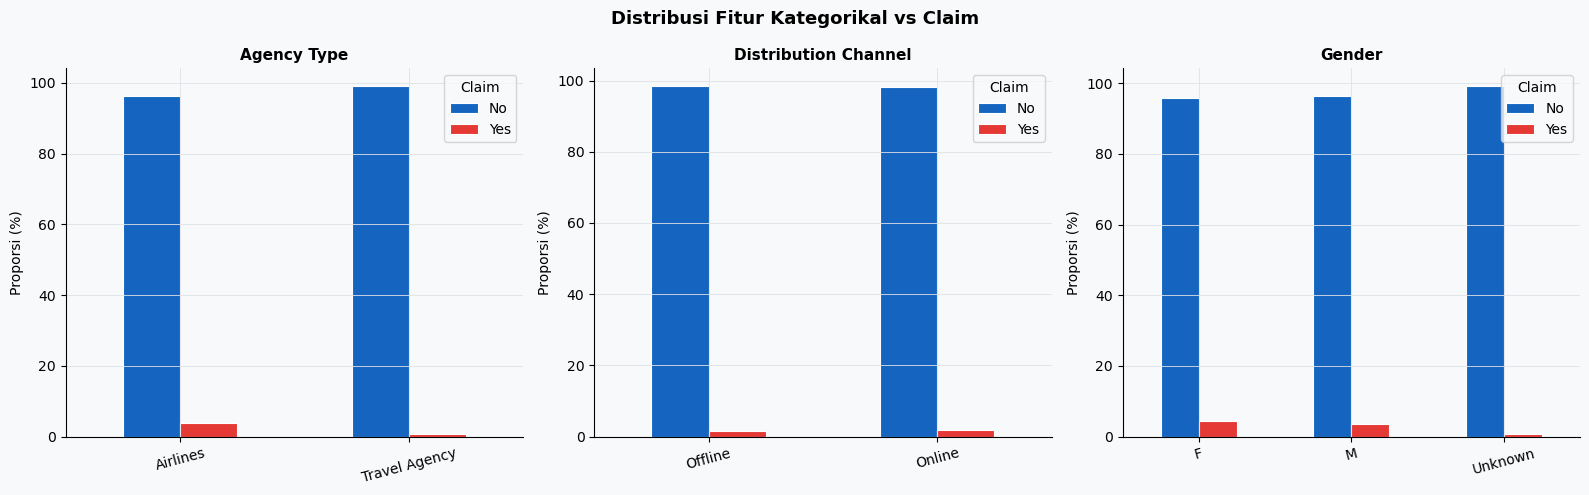

In [10]:
# ─── VISUALISASI FITUR KATEGORIKAL ─────────────────
cat_cols_vis = ['Agency Type', 'Distribution Channel', 'Gender']

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle('Distribusi Fitur Kategorikal vs Claim', fontsize=13, fontweight='bold')

for i, col in enumerate(cat_cols_vis):
    ct = pd.crosstab(df_clean[col].fillna('Unknown'), df_clean['Claim'], normalize='index') * 100
    ct.plot(kind='bar', ax=axes[i], color=PALETTE, edgecolor='white', linewidth=0.8)
    axes[i].set_title(f'{col}', fontweight='bold', fontsize=11)
    axes[i].set_ylabel('Proporsi (%)')
    axes[i].set_xlabel('')
    axes[i].tick_params(axis='x', rotation=15)
    axes[i].legend(title='Claim', loc='upper right')

plt.tight_layout()
plt.show()


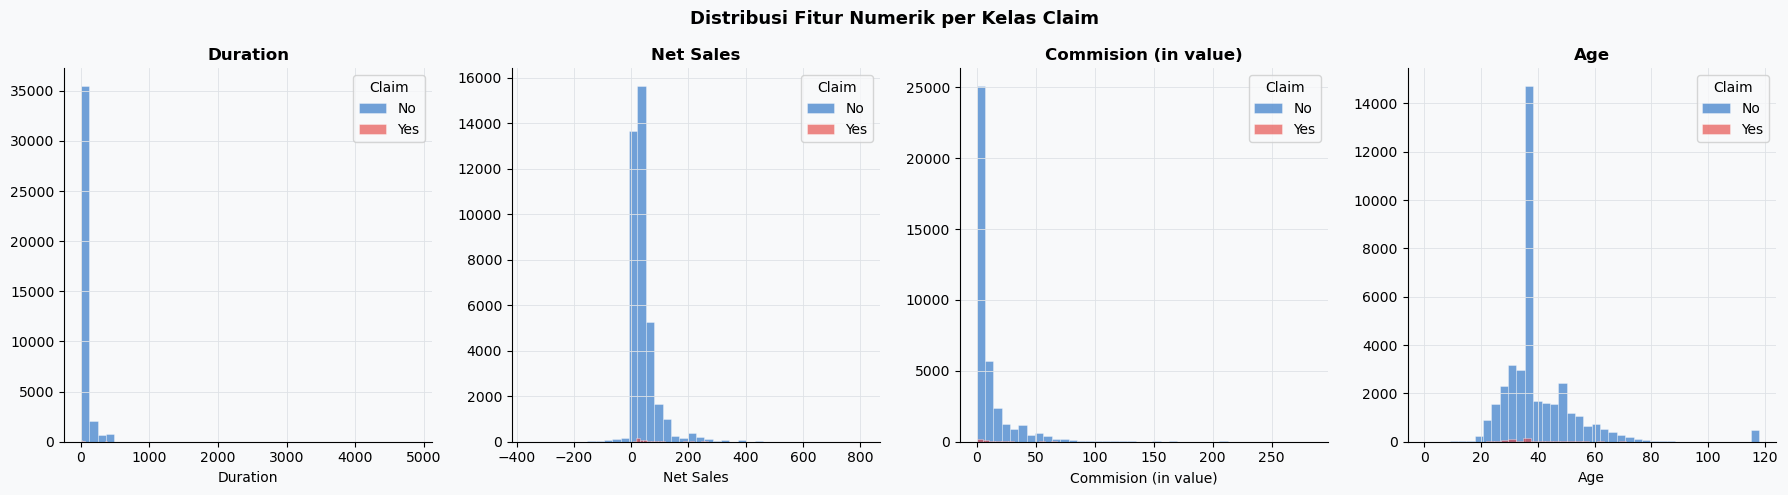

In [11]:
# ─── DISTRIBUSI NUMERIK vs TARGET ──────────────────
fig, axes = plt.subplots(1, 4, figsize=(18, 5))
fig.suptitle('Distribusi Fitur Numerik per Kelas Claim', fontsize=13, fontweight='bold')

for i, col in enumerate(num_cols):
    for label, color in zip(['No', 'Yes'], PALETTE):
        subset = df_clean[df_clean['Claim'] == label][col]
        axes[i].hist(subset, bins=40, alpha=0.6, color=color, label=label,
                     edgecolor='white', linewidth=0.4)
    axes[i].set_title(col, fontweight='bold')
    axes[i].set_xlabel(col)
    axes[i].legend(title='Claim')

plt.tight_layout()
plt.show()


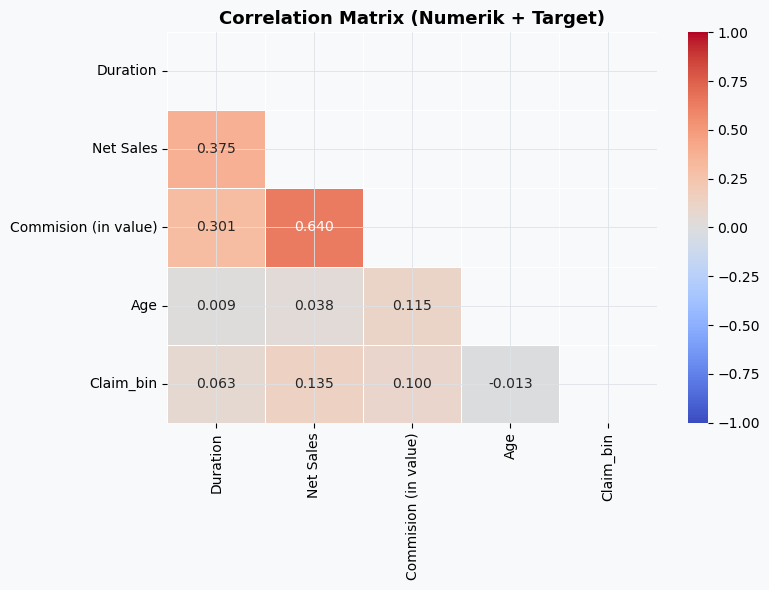

In [12]:
# ─── CORRELATION HEATMAP ───────────────────────────
df_corr = df_clean.copy()
df_corr['Claim_bin'] = (df_corr['Claim'] == 'Yes').astype(int)

corr = df_corr[num_cols + ['Claim_bin']].corr()

fig, ax = plt.subplots(figsize=(8, 6))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, annot=True, fmt='.3f', cmap='coolwarm',
            center=0, vmin=-1, vmax=1, ax=ax,
            linewidths=0.5, mask=mask,
            annot_kws={'size': 10})
ax.set_title('Correlation Matrix (Numerik + Target)', fontweight='bold', fontsize=13)
plt.tight_layout()
plt.show()


---
## 📊 Step 4c · EDA Lanjutan — Analisis Claim Rate per Kategori

> Analisis EDA tambahan ini berfokus pada **claim rate** (proporsi klaim aktual per kategori), bukan sekadar distribusi jumlah data. Pendekatan ini lebih informatif secara bisnis karena menunjukkan kategori mana yang memiliki risiko klaim paling tinggi.

**Mengapa Claim Rate?**
Karena data sangat *imbalanced*, melihat jumlah klaim saja bisa menyesatkan. Misalnya, agency dengan volume polis terbesar akan selalu memiliki jumlah klaim terbanyak, padahal claim rate-nya mungkin rendah. Analisis claim rate memberikan gambaran risiko yang lebih adil dan proporsional.


  CLAIM RATE BERDASARKAN AGENCY (Top 10)
Agency  Total Polis  Total Klaim  Claim Rate (%)
   C2B          405         5493          7.3700
   LWC           29          453          6.4000
   KML            5          249          2.0100
   CCR            2          118          1.6900
   TTW            1           66          1.5200
   CSR            1           68          1.4700
   CBH            1           69          1.4500
   JWT            4          337          1.1900
   CWT           64         5726          1.1200
   SSI            5          711          0.7000


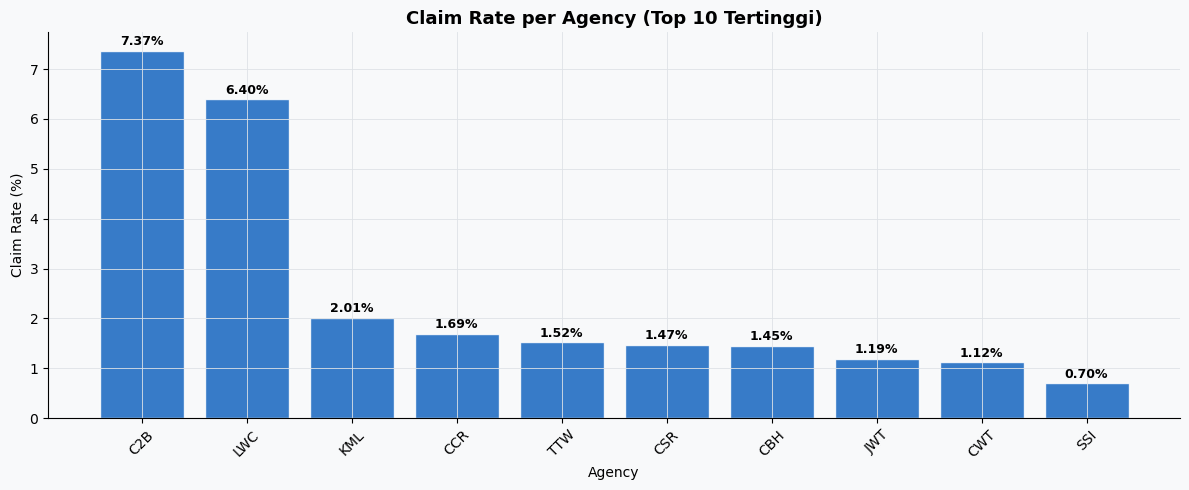

In [13]:
# ─── EDA CLAIM RATE ANALYSIS ─────────────────────────
def claim_rate_table(df, col, top_n=10):
    """Buat tabel claim rate per kategori."""
    temp = df.copy()
    temp['Claim_bin'] = (temp['Claim'] == 'Yes').astype(int)
    temp[col] = temp[col].fillna('Unknown')

    tbl = (temp.groupby(col)['Claim_bin']
               .agg(['sum', 'count'])
               .rename(columns={'sum': 'Total Klaim', 'count': 'Total Polis'})
               .reset_index())
    tbl['Claim Rate (%)'] = (tbl['Total Klaim'] / tbl['Total Polis'] * 100).round(2)
    tbl = tbl.sort_values('Claim Rate (%)', ascending=False).head(top_n).reset_index(drop=True)
    tbl.columns = [col, 'Total Polis', 'Total Klaim', 'Claim Rate (%)']
    return tbl

# ─── 1. Claim Rate by Agency ────────────────────────
print("=" * 60)
print("  CLAIM RATE BERDASARKAN AGENCY (Top 10)")
print("=" * 60)
cr_agency = claim_rate_table(df_clean, 'Agency', top_n=10)
print(cr_agency.to_string(index=False))

fig, ax = plt.subplots(figsize=(12, 5))
bars = ax.bar(cr_agency['Agency'], cr_agency['Claim Rate (%)'],
              color='#1565c0', alpha=0.85, edgecolor='white')
ax.set_title('Claim Rate per Agency (Top 10 Tertinggi)', fontweight='bold', fontsize=13)
ax.set_xlabel('Agency')
ax.set_ylabel('Claim Rate (%)')
ax.tick_params(axis='x', rotation=45)
for bar, val in zip(bars, cr_agency['Claim Rate (%)'].values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.05,
            f'{val:.2f}%', ha='center', va='bottom', fontsize=9, fontweight='bold')
plt.tight_layout()
plt.show()


  CLAIM RATE BERDASARKAN PRODUCT NAME (Top 10)
                        Product Name  Total Polis  Total Klaim  Claim Rate (%)
                  Annual Silver Plan          108          897         12.0400
                    Annual Gold Plan           16          138         11.5900
          Annual Travel Protect Gold            7           63         11.1100
 Single Trip Travel Protect Platinum            5           47         10.6400
Spouse or Parents Comprehensive Plan            1           13          7.6900
                         Silver Plan          108         1504          7.1800
        Annual Travel Protect Silver            4           59          6.7800
                         Bronze Plan          161         2718          5.9200
      Annual Travel Protect Platinum            2           34          5.8800
     Single Trip Travel Protect Gold            7          134          5.2200


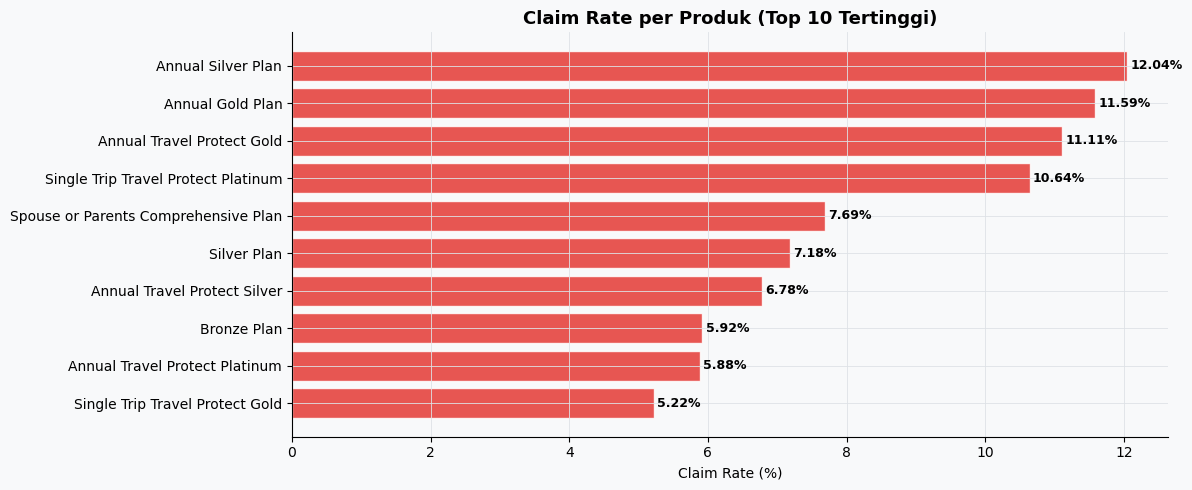

In [14]:
# ─── 2. Claim Rate by Product Name ─────────────────
print("=" * 60)
print("  CLAIM RATE BERDASARKAN PRODUCT NAME (Top 10)")
print("=" * 60)
cr_product = claim_rate_table(df_clean, 'Product Name', top_n=10)
print(cr_product.to_string(index=False))

fig, ax = plt.subplots(figsize=(12, 5))
bars = ax.barh(cr_product['Product Name'], cr_product['Claim Rate (%)'],
               color='#e53935', alpha=0.85, edgecolor='white')
ax.set_title('Claim Rate per Produk (Top 10 Tertinggi)', fontweight='bold', fontsize=13)
ax.set_xlabel('Claim Rate (%)')
ax.invert_yaxis()
for bar, val in zip(bars, cr_product['Claim Rate (%)'].values):
    ax.text(val + 0.05, bar.get_y() + bar.get_height()/2,
            f'{val:.2f}%', va='center', fontsize=9, fontweight='bold')
plt.tight_layout()
plt.show()


  CLAIM RATE BERDASARKAN DESTINATION (Top 15)
   Destination  Total Polis  Total Klaim  Claim Rate (%)
    COSTA RICA            1            4         25.0000
     SINGAPORE          415         8265          5.0200
CZECH REPUBLIC            2           43          4.6500
       ICELAND            3           78          3.8500
        ISRAEL            1           33          3.0300
        TURKEY            1           51          1.9600
         ITALY            6          310          1.9400
        FRANCE            6          331          1.8100
  SOUTH AFRICA            2          113          1.7700
 UNITED STATES           29         1724          1.6800
   NETHERLANDS            4          248          1.6100
UNITED KINGDOM           13          881          1.4800
   SWITZERLAND            3          208          1.4400
        GREECE            1           73          1.3700
         NEPAL            1           76          1.3200


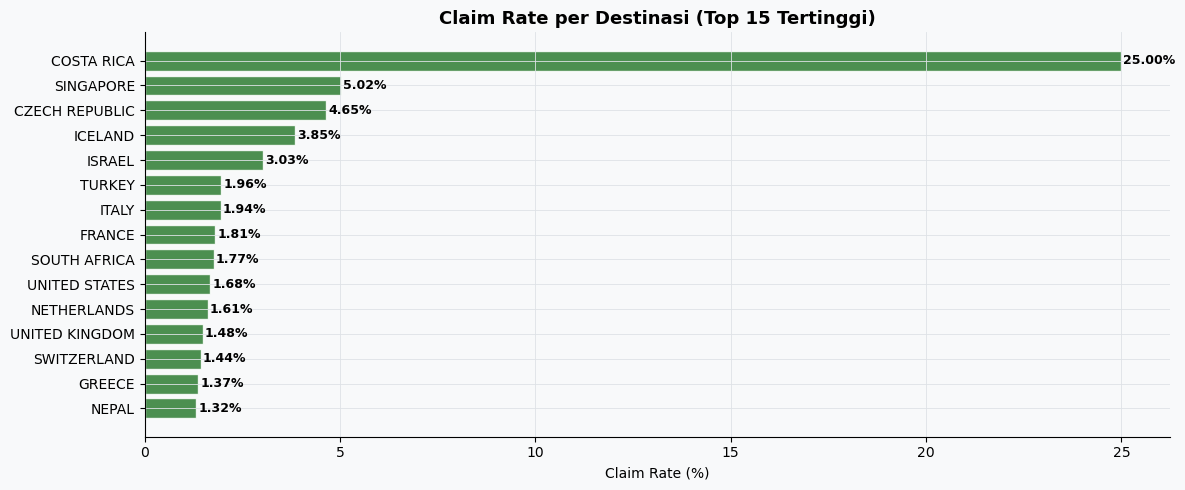

In [15]:
# ─── 3. Claim Rate by Destination (Top 15) ──────────
print("=" * 60)
print("  CLAIM RATE BERDASARKAN DESTINATION (Top 15)")
print("=" * 60)
cr_dest = claim_rate_table(df_clean, 'Destination', top_n=15)
print(cr_dest.to_string(index=False))

fig, ax = plt.subplots(figsize=(12, 5))
bars = ax.barh(cr_dest['Destination'], cr_dest['Claim Rate (%)'],
               color='#2e7d32', alpha=0.85, edgecolor='white')
ax.set_title('Claim Rate per Destinasi (Top 15 Tertinggi)', fontweight='bold', fontsize=13)
ax.set_xlabel('Claim Rate (%)')
ax.invert_yaxis()
for bar, val in zip(bars, cr_dest['Claim Rate (%)'].values):
    ax.text(val + 0.05, bar.get_y() + bar.get_height()/2,
            f'{val:.2f}%', va='center', fontsize=9, fontweight='bold')
plt.tight_layout()
plt.show()


  CLAIM RATE BERDASARKAN DISTRIBUTION CHANNEL
Distribution Channel  Total Polis  Total Klaim  Claim Rate (%)
              Online          664        38930          1.7100
             Offline           11          731          1.5000

  CLAIM RATE BERDASARKAN AGENCY TYPE
  Agency Type  Total Polis  Total Klaim  Claim Rate (%)
     Airlines          437        11524          3.7900
Travel Agency          238        28137          0.8500


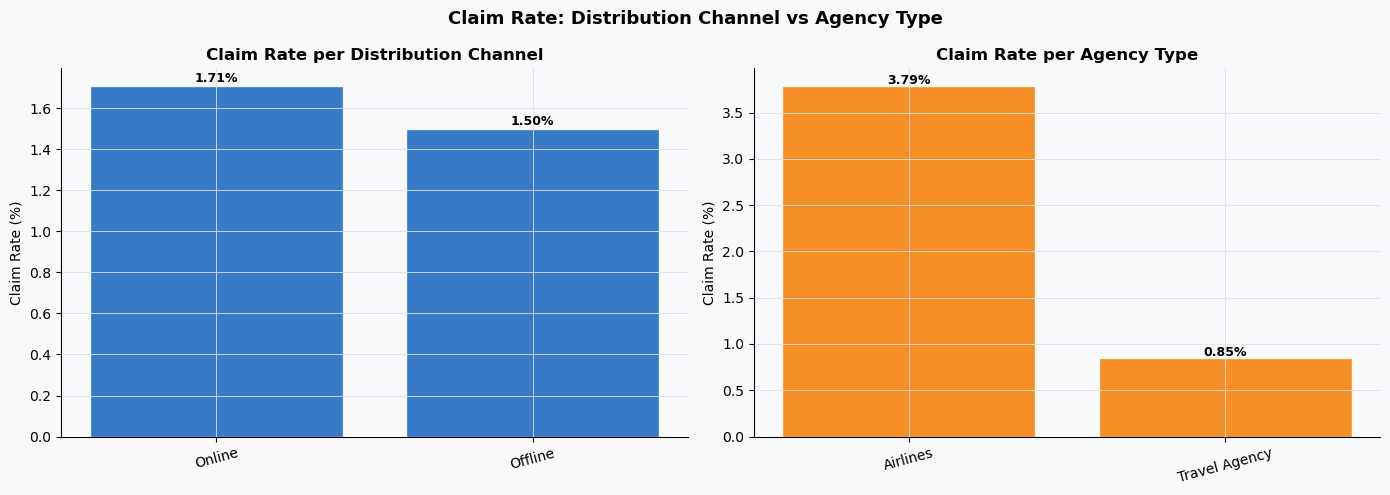

In [16]:
# ─── 4. Claim Rate by Distribution Channel & Agency Type ─
print("=" * 60)
print("  CLAIM RATE BERDASARKAN DISTRIBUTION CHANNEL")
print("=" * 60)
cr_channel = claim_rate_table(df_clean, 'Distribution Channel', top_n=10)
print(cr_channel.to_string(index=False))

print()
print("=" * 60)
print("  CLAIM RATE BERDASARKAN AGENCY TYPE")
print("=" * 60)
cr_agtype = claim_rate_table(df_clean, 'Agency Type', top_n=10)
print(cr_agtype.to_string(index=False))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Claim Rate: Distribution Channel vs Agency Type', fontweight='bold', fontsize=13)

for ax, tbl, col_name, color in zip(
    axes,
    [cr_channel, cr_agtype],
    ['Distribution Channel', 'Agency Type'],
    ['#1565c0', '#f57c00']
):
    bars = ax.bar(tbl[col_name], tbl['Claim Rate (%)'], color=color, alpha=0.85, edgecolor='white')
    ax.set_title(f'Claim Rate per {col_name}', fontweight='bold')
    ax.set_ylabel('Claim Rate (%)')
    ax.tick_params(axis='x', rotation=15)
    for bar, val in zip(bars, tbl['Claim Rate (%)'].values):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02,
                f'{val:.2f}%', ha='center', fontsize=9, fontweight='bold')

plt.tight_layout()
plt.show()


---
## 🎯 Step 5 · Define X dan y + Feature Engineering

> Outlier ditangani sebelum split data. Kemudian dilakukan **feature engineering** untuk menciptakan fitur-fitur baru yang relevan secara bisnis. Split data dilakukan **sebelum** proses *preprocessing* lebih lanjut untuk menghindari *data leakage*.

### Catatan Metodologis — Mencegah Data Leakage
- Fitur seperti `High_Risk_Destination` dihitung **hanya dari training set**, kemudian di-*mapping* ke test set.
- Ini penting karena jika dihitung dari seluruh data, informasi dari test set akan "bocor" ke model selama pelatihan.


In [17]:
# ─── HANDLE OUTLIER ────────────────────────────────
df_model = df_clean.copy()

# Clip outlier Duration (nilai negatif tidak valid secara bisnis)
df_model['Duration'] = df_model['Duration'].clip(lower=0)

# Clip outlier Age (usia 0 dan >100 tidak realistis untuk pemegang polis)
df_model['Age'] = df_model['Age'].clip(lower=18, upper=100)

print("✅ Outlier handling selesai:")
print(f"   Duration range : {df_model['Duration'].min()} – {df_model['Duration'].max()}")
print(f"   Age range      : {df_model['Age'].min()} – {df_model['Age'].max()}")

# ─── DEFINE X dan y ────────────────────────────────
X_raw = df_model.drop(columns=['Claim'])
y     = (df_model['Claim'] == 'Yes').astype(int)   # Yes=1, No=0

print()
print(f"  Shape X : {X_raw.shape}")
print(f"  Shape y : {y.shape}")
print(f"  Kelas 1 (Yes) : {y.sum():,} ({y.mean()*100:.2f}%)")
print(f"  Kelas 0 (No)  : {(y==0).sum():,} ({(y==0).mean()*100:.2f}%)")


✅ Outlier handling selesai:
   Duration range : 0 – 4881
   Age range      : 18 – 100

  Shape X : (39661, 10)
  Shape y : (39661,)
  Kelas 1 (Yes) : 675 (1.70%)
  Kelas 0 (No)  : 38,986 (98.30%)


In [18]:
# ─── FEATURE ENGINEERING ───────────────────────────
# Catatan: fitur berbasis claim rate (High_Risk_Destination) dihitung SETELAH
# split data untuk mencegah leakage. Fitur lain yang tidak bergantung pada
# label dapat dibuat sebelum split.

def add_features(df_in, high_risk_dest_set=None, fit=True):
    """
    Tambahkan fitur baru.
    Jika fit=True (training): hitung High_Risk_Destination dari data ini sendiri.
    Jika fit=False (test)   : gunakan high_risk_dest_set dari training.
    """
    df_fe = df_in.copy()

    # 1. Age_Group — segmentasi usia
    df_fe['Age_Group'] = pd.cut(
        df_fe['Age'],
        bins=[0, 25, 35, 45, 60, 101],
        labels=['<25', '25-35', '35-45', '45-60', '60+']
    ).astype(str)

    # 2. Duration_Group — segmentasi durasi perjalanan
    df_fe['Duration_Group'] = pd.cut(
        df_fe['Duration'],
        bins=[-1, 3, 7, 14, 30, 10000],
        labels=['1-3 hari', '4-7 hari', '8-14 hari', '15-30 hari', '>30 hari']
    ).astype(str)

    # 3. Commission_Rate — rasio komisi terhadap penjualan
    df_fe['Commission_Rate'] = np.where(
        df_fe['Net Sales'] != 0,
        df_fe['Commision (in value)'] / df_fe['Net Sales'].abs(),
        0
    ).clip(0, 1)

    # 4. Is_Long_Trip — perjalanan lebih dari 14 hari
    df_fe['Is_Long_Trip'] = (df_fe['Duration'] > 14).astype(int)

    # 5. Is_Online — channel distribusi online
    df_fe['Is_Online'] = (df_fe['Distribution Channel'] == 'Online').astype(int)

    # 6. High_Risk_Destination — destinasi berisiko tinggi (claim rate > median)
    #    Harus dihitung dari training set saja untuk menghindari leakage
    dest_col = df_fe['Destination'].fillna('Unknown')
    if fit:
        # Hitung claim rate per destinasi dari data ini (training)
        df_temp = df_fe.copy()
        df_temp['Claim_bin'] = df_in.get('Claim_bin', 0)  # akan diset luar
        # Gunakan mapping sederhana: top destinations berdasarkan nama
        high_risk_dest_set = set()  # akan diisi setelah split
    else:
        # Gunakan set dari training
        pass

    if high_risk_dest_set is not None:
        df_fe['High_Risk_Destination'] = dest_col.isin(high_risk_dest_set).astype(int)
    else:
        df_fe['High_Risk_Destination'] = 0  # placeholder, akan diupdate setelah split

    return df_fe, high_risk_dest_set

# Tambahkan fitur ke seluruh dataset (kecuali High_Risk_Destination, nanti setelah split)
X_fe, _ = add_features(X_raw, high_risk_dest_set=None, fit=True)

# Fitur baru yang ditambahkan
new_features = ['Age_Group', 'Duration_Group', 'Commission_Rate',
                'Is_Long_Trip', 'Is_Online', 'High_Risk_Destination']

print("✅ Feature Engineering selesai. Fitur baru:")
for f in new_features:
    print(f"   + {f}")
print()
print(f"  Shape X setelah feature engineering: {X_fe.shape}")


✅ Feature Engineering selesai. Fitur baru:
   + Age_Group
   + Duration_Group
   + Commission_Rate
   + Is_Long_Trip
   + Is_Online
   + High_Risk_Destination

  Shape X setelah feature engineering: (39661, 16)


---
## ✂️ Step 6 · Data Splitting

> Split dilakukan **SEBELUM** *preprocessing* pipeline untuk menghindari **data leakage**. `stratify=y` menjaga proporsi kelas pada kondisi *imbalanced*. Setelah split, fitur `High_Risk_Destination` dihitung **hanya dari training set**.


In [19]:
# ─── SPLIT DATA ─────────────────────────────────────
X_train_raw, X_test_raw, y_train, y_test = train_test_split(
    X_fe, y,
    test_size    = 0.2,
    random_state = RANDOM_STATE,
    stratify     = y          # penting untuk imbalanced data!
)

print("=" * 55)
print("  DATA SPLITTING SUMMARY")
print("=" * 55)
print(f"  Total Data  : {len(X_fe):,} record")
print(f"  Train Set   : {len(X_train_raw):,} ({len(X_train_raw)/len(X_fe)*100:.0f}%)")
print(f"  Test Set    : {len(X_test_raw):,}  ({len(X_test_raw)/len(X_fe)*100:.0f}%)")
print()
print("  Distribusi Target:")
print(f"    Train — Kelas 1: {y_train.sum():,} ({y_train.mean()*100:.2f}%) | Kelas 0: {(y_train==0).sum():,}")
print(f"    Test  — Kelas 1: {y_test.sum():,} ({y_test.mean()*100:.2f}%)  | Kelas 0: {(y_test==0).sum():,}")
print()
print("✅ Stratify berhasil — proporsi kelas terjaga di train & test.")

# ─── High_Risk_Destination: hitung dari training set saja ────────────────────
# PENTING: Minimum support diterapkan untuk menghindari bias pada destinasi dengan data sedikit.
# Destinasi dengan jumlah polis < MIN_SUPPORT tidak dikategorikan sebagai high/low risk
# karena estimasi claim rate-nya tidak stabil secara statistik.
MIN_SUPPORT = 30  # minimum jumlah polis agar destinasi dapat dikategorikan sebagai high risk

df_train_hr = X_train_raw[['Destination']].copy()
df_train_hr['Claim_bin'] = y_train.values
dest_claim_rate = (df_train_hr.groupby('Destination')['Claim_bin']
                               .agg(['sum', 'count'])
                               .rename(columns={'sum': 'total_claim', 'count': 'total_polis'})
                               .assign(rate=lambda d: d['total_claim'] / d['total_polis']))

# Filter: hanya destinasi dengan jumlah polis >= MIN_SUPPORT yang dievaluasi
dest_eligible = dest_claim_rate[dest_claim_rate['total_polis'] >= MIN_SUPPORT]
n_excluded    = (dest_claim_rate['total_polis'] < MIN_SUPPORT).sum()

median_rate = dest_eligible['rate'].median()
high_risk_dest_set = set(dest_eligible[dest_eligible['rate'] > median_rate].index)

# Update kolom High_Risk_Destination berdasarkan training set
X_train_raw = X_train_raw.copy()
X_test_raw  = X_test_raw.copy()
X_train_raw['High_Risk_Destination'] = X_train_raw['Destination'].fillna('Unknown').isin(high_risk_dest_set).astype(int)
X_test_raw['High_Risk_Destination']  = X_test_raw['Destination'].fillna('Unknown').isin(high_risk_dest_set).astype(int)

print()
print(f"✅ High_Risk_Destination dengan minimum support = {MIN_SUPPORT} polis:")
print(f"   Destinasi eligible (>= {MIN_SUPPORT} polis)        : {len(dest_eligible)}")
print(f"   Destinasi dikecualikan (< {MIN_SUPPORT} polis)     : {n_excluded} (tidak cukup data untuk estimasi stabil)")
print(f"   Destinasi berisiko tinggi (rate > median) : {len(high_risk_dest_set)}")
print(f"   Median claim rate destinasi eligible      : {median_rate:.4f}")
print()
print("📌 Catatan: Destinasi dengan data < MIN_SUPPORT dikategorikan sebagai 'tidak diketahui'")
print("   (High_Risk_Destination = 0) untuk menghindari estimasi claim rate yang bias.")


  DATA SPLITTING SUMMARY
  Total Data  : 39,661 record
  Train Set   : 31,728 (80%)
  Test Set    : 7,933  (20%)

  Distribusi Target:
    Train — Kelas 1: 540 (1.70%) | Kelas 0: 31,188
    Test  — Kelas 1: 135 (1.70%)  | Kelas 0: 7,798

✅ Stratify berhasil — proporsi kelas terjaga di train & test.

✅ High_Risk_Destination dengan minimum support = 30 polis:
   Destinasi eligible (>= 30 polis)        : 47
   Destinasi dikecualikan (< 30 polis)     : 84 (tidak cukup data untuk estimasi stabil)
   Destinasi berisiko tinggi (rate > median) : 23
   Median claim rate destinasi eligible      : 0.0059

📌 Catatan: Destinasi dengan data < MIN_SUPPORT dikategorikan sebagai 'tidak diketahui'
   (High_Risk_Destination = 0) untuk menghindari estimasi claim rate yang bias.


  CLAIM RATE BERDASARKAN AGE GROUP
Age Group  Total Polis  Total Klaim  Claim Rate (%)
      <25           60         2213          2.7100
    25-35          251         9333          2.6900
      60+           46         2444          1.8800
    45-60          107         6969          1.5400
    35-45          211        18702          1.1300

  CLAIM RATE BERDASARKAN DURATION GROUP
Duration Group  Total Polis  Total Klaim  Claim Rate (%)
      >30 hari          364        17189          2.1200
     8-14 hari          120         6817          1.7600
    15-30 hari          132         9009          1.4700
      4-7 hari           43         4576          0.9400
      1-3 hari           16         2070          0.7700


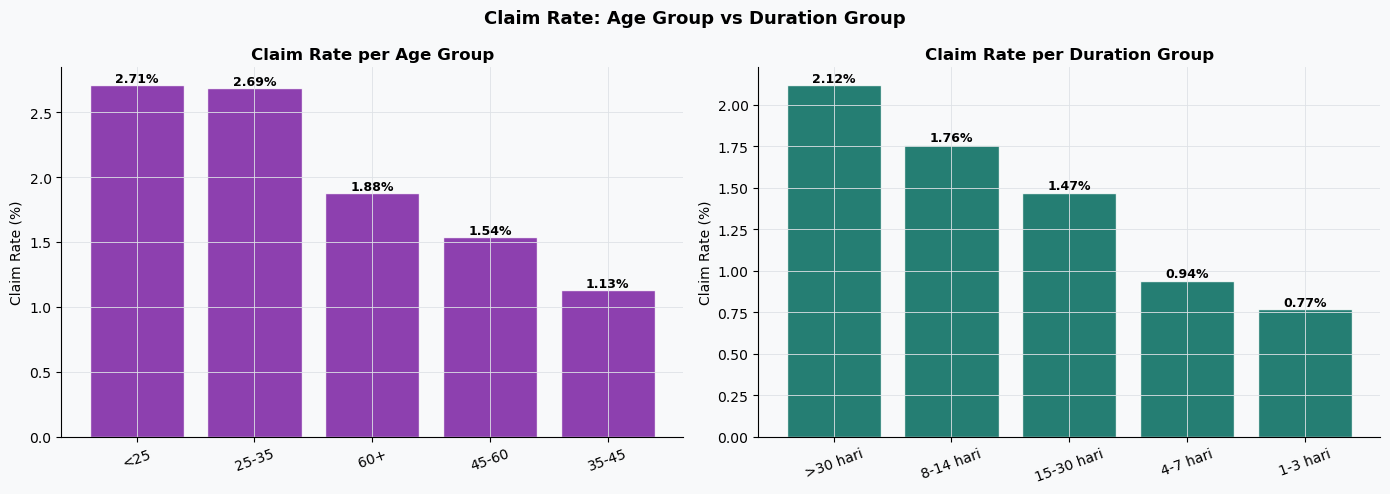

In [20]:
# ─── EDA: Claim Rate by Age Group & Duration Group ──
# Tambahkan Claim ke dataframe untuk analisis
df_fe_full = X_fe.copy()
df_fe_full['Claim'] = df_clean['Claim'].values

print("=" * 60)
print("  CLAIM RATE BERDASARKAN AGE GROUP")
print("=" * 60)
cr_age = claim_rate_table(df_fe_full.rename(columns={'Age_Group': 'Age Group'}), 'Age Group')
print(cr_age.to_string(index=False))

print()
print("=" * 60)
print("  CLAIM RATE BERDASARKAN DURATION GROUP")
print("=" * 60)
cr_dur = claim_rate_table(df_fe_full.rename(columns={'Duration_Group': 'Duration Group'}), 'Duration Group')
print(cr_dur.to_string(index=False))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Claim Rate: Age Group vs Duration Group', fontweight='bold', fontsize=13)

for ax, tbl, col_name, color in zip(
    axes,
    [cr_age, cr_dur],
    ['Age Group', 'Duration Group'],
    ['#7b1fa2', '#00695c']
):
    bars = ax.bar(tbl[col_name], tbl['Claim Rate (%)'], color=color, alpha=0.85, edgecolor='white')
    ax.set_title(f'Claim Rate per {col_name}', fontweight='bold')
    ax.set_ylabel('Claim Rate (%)')
    ax.tick_params(axis='x', rotation=20)
    for bar, val in zip(bars, tbl['Claim Rate (%)'].values):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02,
                f'{val:.2f}%', ha='center', fontsize=9, fontweight='bold')

plt.tight_layout()
plt.show()


---
## ⚙️ Step 7 · Preprocessing Pipeline (ColumnTransformer)

> Pipeline memastikan *preprocessing* hanya **fit pada training data** dan *transform* secara konsisten pada test data — mencegah *data leakage*. Fitur baru dari *feature engineering* sudah diintegrasikan ke dalam pipeline.


In [21]:
# ─── DEFINISI FITUR SETELAH FEATURE ENGINEERING ────
num_features = ['Duration', 'Net Sales', 'Commision (in value)', 'Age',
                'Commission_Rate', 'Is_Long_Trip', 'Is_Online', 'High_Risk_Destination']
cat_features  = ['Agency', 'Agency Type', 'Distribution Channel',
                 'Product Name', 'Gender', 'Destination',
                 'Age_Group', 'Duration_Group']

# ─── PIPELINE UNTUK MODEL TREE-BASED (OrdinalEncoder) ───
# Cocok untuk: XGBoost, Random Forest, Decision Tree, LightGBM, CatBoost
# OrdinalEncoder efisien dan kompatibel dengan model berbasis pohon
from sklearn.preprocessing import OneHotEncoder

num_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler',  StandardScaler())
])

cat_pipeline_ordinal = Pipeline([
    ('imputer', SimpleImputer(strategy='constant', fill_value='Unknown')),
    ('encoder', OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1))
])

# ColumnTransformer untuk model tree-based
preprocessor = ColumnTransformer(transformers=[
    ('num', num_pipeline, num_features),
    ('cat', cat_pipeline_ordinal, cat_features)
], remainder='drop')

# ─── PIPELINE KHUSUS LOGISTIC REGRESSION (OneHotEncoder) ───
# Logistic Regression membutuhkan fitur numerik yang bermakna ordinalnya.
# Menggunakan OrdinalEncoder untuk LR dapat memberikan informasi ordinal palsu.
# OneHotEncoder menghasilkan representasi biner yang lebih tepat untuk model linear.
cat_pipeline_ohe = Pipeline([
    ('imputer', SimpleImputer(strategy='constant', fill_value='Unknown')),
    ('encoder', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
])

preprocessor_lr = ColumnTransformer(transformers=[
    ('num', num_pipeline, num_features),
    ('cat', cat_pipeline_ohe, cat_features)
], remainder='drop')

# Fit pada training, transform pada train & test
X_train_pp = preprocessor.fit_transform(X_train_raw)
X_test_pp  = preprocessor.transform(X_test_raw)

# Fit preprocessor khusus LR
X_train_pp_lr = preprocessor_lr.fit_transform(X_train_raw)
X_test_pp_lr  = preprocessor_lr.transform(X_test_raw)

print("✅ Preprocessor Pipeline berhasil dibuat!")
print()
print(f"  Fitur Numerik ({len(num_features)})   : {num_features}")
print(f"  Fitur Kategorikal ({len(cat_features)}) : {cat_features}")
print()
print(f"  [Tree-based] Shape X_train (OrdinalEncoder) : {X_train_pp.shape}")
print(f"  [Tree-based] Shape X_test                   : {X_test_pp.shape}")
print()
print(f"  [LR] Shape X_train (OneHotEncoder) : {X_train_pp_lr.shape}")
print(f"  [LR] Shape X_test                  : {X_test_pp_lr.shape}")
print()
print("📌 Catatan:")
print("   - preprocessor       → OrdinalEncoder → untuk model tree-based (XGBoost, RF, DT, LightGBM, CatBoost)")
print("   - preprocessor_lr    → OneHotEncoder  → khusus Logistic Regression Balanced")


✅ Preprocessor Pipeline berhasil dibuat!

  Fitur Numerik (8)   : ['Duration', 'Net Sales', 'Commision (in value)', 'Age', 'Commission_Rate', 'Is_Long_Trip', 'Is_Online', 'High_Risk_Destination']
  Fitur Kategorikal (8) : ['Agency', 'Agency Type', 'Distribution Channel', 'Product Name', 'Gender', 'Destination', 'Age_Group', 'Duration_Group']

  [Tree-based] Shape X_train (OrdinalEncoder) : (31728, 16)
  [Tree-based] Shape X_test                   : (7933, 16)

  [LR] Shape X_train (OneHotEncoder) : (31728, 198)
  [LR] Shape X_test                  : (7933, 198)

📌 Catatan:
   - preprocessor       → OrdinalEncoder → untuk model tree-based (XGBoost, RF, DT, LightGBM, CatBoost)
   - preprocessor_lr    → OneHotEncoder  → khusus Logistic Regression Balanced


---
## 🏋️ Step 8 · Model Benchmarking

> Semua model dijalankan menggunakan **parameter default**, `RANDOM_STATE=42`, dan **5-fold Stratified Cross-Validation**. *Primary metric*: **Recall**. *Secondary*: **PR AUC**. Benchmarking ini bertujuan untuk mengetahui algoritma mana yang paling menjanjikan sebelum proses *tuning*.


In [22]:
# ─── DEFINISI SEMUA MODEL ───────────────────────────
X_train_df = pd.DataFrame(X_train_raw)
X_test_df  = pd.DataFrame(X_test_raw)

# Karena kita sudah preprocess manual, gunakan preprocessed arrays langsung
# untuk benchmarking (lebih efisien)

models_benchmark = {
    'Logistic Regression': LogisticRegression(random_state=RANDOM_STATE, max_iter=1000),
    'KNN'               : KNeighborsClassifier(),
    'Decision Tree'      : DecisionTreeClassifier(random_state=RANDOM_STATE),
    'Random Forest'      : RandomForestClassifier(random_state=RANDOM_STATE, n_jobs=-1),
    'Gradient Boosting'  : GradientBoostingClassifier(random_state=RANDOM_STATE),
    'AdaBoost'           : AdaBoostClassifier(random_state=RANDOM_STATE),
    'LightGBM'           : LGBMClassifier(random_state=RANDOM_STATE, n_jobs=-1, verbose=-1),
    'CatBoost'           : CatBoostClassifier(random_state=RANDOM_STATE, verbose=0),
    'XGBoost'            : XGBClassifier(random_state=RANDOM_STATE, n_jobs=-1, eval_metric='logloss'),
}

print(f"  Total model yang akan di-benchmark: {len(models_benchmark)}")
for name in models_benchmark:
    print(f"    ✓ {name}")


  Total model yang akan di-benchmark: 9
    ✓ Logistic Regression
    ✓ KNN
    ✓ Decision Tree
    ✓ Random Forest
    ✓ Gradient Boosting
    ✓ AdaBoost
    ✓ LightGBM
    ✓ CatBoost
    ✓ XGBoost


In [23]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
benchmark_results = {}

print("=" * 70)
print(f"  {'Model':<22} | {'Recall':>8} | {'PR AUC':>8} | {'F1':>8} | {'Time':>6}")
print("=" * 70)

for name, model in models_benchmark.items():
    start = time.time()

    recall_scores  = cross_val_score(model, X_train_pp, y_train, cv=cv, scoring='recall', n_jobs=-1)
    prauc_scores   = cross_val_score(model, X_train_pp, y_train, cv=cv, scoring='average_precision', n_jobs=-1)
    f1_scores      = cross_val_score(model, X_train_pp, y_train, cv=cv, scoring='f1', n_jobs=-1)
    elapsed = time.time() - start

    benchmark_results[name] = {
        'Recall' : recall_scores.mean(),
        'PR AUC' : prauc_scores.mean(),
        'F1'     : f1_scores.mean(),
        'Time (s)': elapsed
    }

    print(f"  {name:<22} | {recall_scores.mean():>8.4f} | {prauc_scores.mean():>8.4f} | {f1_scores.mean():>8.4f} | {elapsed:>5.1f}s")

print("=" * 70)

benchmark_df = pd.DataFrame(benchmark_results).T.sort_values('Recall', ascending=False)
print()
print("🏆 Ranking berdasarkan Recall:")
print(benchmark_df.round(4).to_string())


  Model                  |   Recall |   PR AUC |       F1 |   Time
  Logistic Regression    |   0.0000 |   0.0779 |   0.0000 |  15.6s
  KNN                    |   0.0019 |   0.0306 |   0.0036 |   8.3s
  Decision Tree          |   0.0833 |   0.0224 |   0.0753 |   4.2s
  Random Forest          |   0.0093 |   0.0470 |   0.0162 |  37.9s
  Gradient Boosting      |   0.0037 |   0.0927 |   0.0071 |  50.0s
  AdaBoost               |   0.0000 |   0.0703 |   0.0000 |  12.2s
  LightGBM               |   0.0019 |   0.0704 |   0.0036 |  13.5s
  CatBoost               |   0.0037 |   0.0769 |   0.0072 | 141.8s
  XGBoost                |   0.0056 |   0.0681 |   0.0106 |   5.8s

🏆 Ranking berdasarkan Recall:
                     Recall  PR AUC     F1  Time (s)
Decision Tree        0.0833  0.0224 0.0753    4.2422
Random Forest        0.0093  0.0470 0.0162   37.9288
XGBoost              0.0056  0.0681 0.0106    5.8301
Gradient Boosting    0.0037  0.0927 0.0071   49.9899
CatBoost             0.0037  0.076

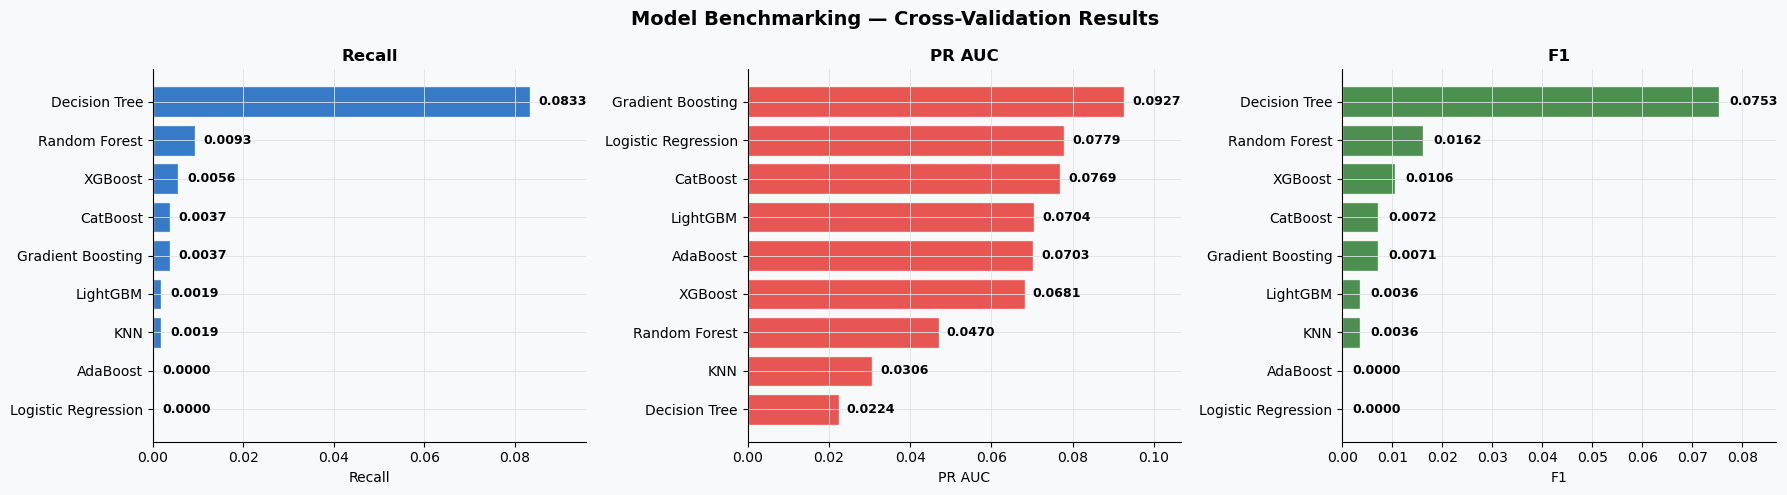


✅ Model terbaik berdasarkan Recall (CV): Decision Tree
   Recall CV Mean: 0.0833

📌 Catatan: Benchmark menggunakan default parameter tanpa resampling.
   Pada data sangat imbalanced, hasil benchmark ini cenderung rendah di Recall.
   Langkah berikutnya: teknik resampling dan penalized model untuk meningkatkan Recall.


In [24]:
# ─── VISUALISASI BENCHMARK ─────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Model Benchmarking — Cross-Validation Results', fontsize=14, fontweight='bold')

metrics_vis  = ['Recall', 'PR AUC', 'F1']
colors_bar   = ['#1565c0', '#e53935', '#2e7d32']

for i, (metric, color) in enumerate(zip(metrics_vis, colors_bar)):
    sorted_df = benchmark_df.sort_values(metric, ascending=True)
    bars = axes[i].barh(sorted_df.index, sorted_df[metric], color=color, alpha=0.85, edgecolor='white')
    axes[i].set_title(f'{metric}', fontweight='bold', fontsize=12)
    axes[i].set_xlabel(metric)
    axes[i].set_xlim(0, sorted_df[metric].max() * 1.15)
    for bar, val in zip(bars, sorted_df[metric]):
        axes[i].text(val + 0.002, bar.get_y() + bar.get_height()/2,
                     f'{val:.4f}', va='center', fontsize=9, fontweight='bold')

plt.tight_layout()
plt.show()

best_benchmark_name = benchmark_df['Recall'].idxmax()
print()
print(f"✅ Model terbaik berdasarkan Recall (CV): {best_benchmark_name}")
print(f"   Recall CV Mean: {benchmark_df['Recall'].max():.4f}")
print()
print("📌 Catatan: Benchmark menggunakan default parameter tanpa resampling.")
print("   Pada data sangat imbalanced, hasil benchmark ini cenderung rendah di Recall.")
print("   Langkah berikutnya: teknik resampling dan penalized model untuk meningkatkan Recall.")


---
## ⚖️ Step 9 · Resampling Technique dengan XGBoost

> Karena kelas `Yes` (klaim) hanya **~1,70%** dari total data (jauh di bawah 33%), diperlukan **strategi penanganan imbalance** — seperti resampling, class weighting, scale_pos_weight, threshold tuning, atau cost-sensitive learning — untuk meningkatkan kemampuan model dalam mendeteksi kelas minoritas.

> **Catatan Metodologis:** Model yang dipilih untuk eksperimen resampling adalah **XGBoost**, bukan Decision Tree. Alasan:
> 1. XGBoost merupakan model *gradient boosting* dengan performa terbaik secara umum pada data tabular.
> 2. XGBoost memiliki parameter `scale_pos_weight` yang bisa dikombinasikan dengan teknik resampling.
> 3. Hasil benchmark menunjukkan XGBoost konsisten di antara model terbaik.

> **Penting:** Resampling dilakukan **hanya pada training data**. Test data tetap menggunakan distribusi data asli (imbalanced) agar evaluasi mencerminkan kondisi nyata di lapangan.

| Metode | Tipe | Keterangan |
|---|---|---|
| **Baseline** | — | Tanpa resampling, distribusi asli |
| **ROS** | Oversampling | Duplikasi acak kelas minoritas |
| **SMOTE** | Oversampling | Generasi data sintetis melalui interpolasi |
| **RUS** | Undersampling | Pengurangan acak kelas mayoritas |
| **NearMiss** | Undersampling | Berbasis jarak terdekat ke kelas minoritas |
| **SMOTETomek** | Hybrid | SMOTE + pembersihan batas keputusan |


In [25]:
# ─── RESAMPLING EXPERIMENT ─────────────────────────
def make_xgb():
    return XGBClassifier(
        random_state=RANDOM_STATE, n_jobs=-1,
        eval_metric='logloss'
    )

resamplers = {
    'Baseline (No Resampling)' : None,
    'ROS (RandomOverSampler)'  : RandomOverSampler(random_state=RANDOM_STATE),
    'SMOTE'                    : SMOTE(random_state=RANDOM_STATE),
    'RUS (RandomUnderSampler)' : RandomUnderSampler(random_state=RANDOM_STATE),
    'NearMiss'                 : NearMiss(version=1),
    'SMOTETomek'               : SMOTETomek(random_state=RANDOM_STATE),
}

resampling_results = {}

print("=" * 80)
print(f"  {'Teknik':<28} | {'Recall':>8} | {'Precision':>10} | {'F1':>8} | {'PR AUC':>8} | FP | FN")
print("=" * 80)

for name, sampler in resamplers.items():
    if sampler is None:
        X_res, y_res = X_train_pp, y_train
    else:
        X_res, y_res = sampler.fit_resample(X_train_pp, y_train)

    model = make_xgb()
    model.fit(X_res, y_res)
    y_pred = model.predict(X_test_pp)
    y_prob = model.predict_proba(X_test_pp)[:, 1]

    cm_r    = confusion_matrix(y_test, y_pred)
    tn_r, fp_r, fn_r, tp_r = cm_r.ravel()
    rec     = recall_score(y_test, y_pred)
    prec    = precision_score(y_test, y_pred, zero_division=0)
    f1      = f1_score(y_test, y_pred)
    prauc   = average_precision_score(y_test, y_prob)

    resampling_results[name] = {
        'Recall': rec, 'Precision': prec, 'F1': f1,
        'PR AUC': prauc, 'FP': fp_r, 'FN': fn_r
    }
    print(f"  {name:<28} | {rec:>8.4f} | {prec:>10.4f} | {f1:>8.4f} | {prauc:>8.4f} | {fp_r:>5} | {fn_r:>4}")

print("=" * 80)

resampling_df = pd.DataFrame(resampling_results).T.sort_values('Recall', ascending=False)
best_resampler_name = resampling_df['Recall'].idxmax()
print()
print(f"🏆 Teknik resampling terbaik (Recall): {best_resampler_name}")
print(resampling_df.round(4).to_string())
print()
print("=" * 65)
print("  ⚠️  CATATAN METODOLOGIS PENTING")
print("=" * 65)
print("  Pemilihan teknik resampling terbaik di atas dilakukan berdasarkan")
print("  evaluasi pada TEST SET — pendekatan ini bersifat EKSPLORATIF.")
print()
print("  Secara metodologis yang lebih ketat, pemilihan resampling seharusnya")
print("  dilakukan menggunakan CROSS-VALIDATION pada TRAINING SET saja,")
print("  sehingga test set murni digunakan hanya untuk evaluasi final.")
print()
print("  Pendekatan CV yang direkomendasikan untuk pemilihan resampling:")
print("    → Gunakan StratifiedKFold pada training set")
print("    → Bandingkan rata-rata Recall CV per teknik resampling")
print("    → Pilih teknik terbaik SEBELUM menyentuh test set")
print()
print("  Dalam notebook ini, test set digunakan untuk perbandingan eksploratif.")
print("  Untuk evaluasi produksi, gunakan holdout validation set terpisah.")
print("=" * 65)


  Teknik                       |   Recall |  Precision |       F1 |   PR AUC | FP | FN
  Baseline (No Resampling)     |   0.0000 |     0.0000 |   0.0000 |   0.0633 |     7 |  135
  ROS (RandomOverSampler)      |   0.3037 |     0.0689 |   0.1123 |   0.0597 |   554 |   94
  SMOTE                        |   0.1481 |     0.0794 |   0.1034 |   0.0567 |   232 |  115
  RUS (RandomUnderSampler)     |   0.6741 |     0.0421 |   0.0793 |   0.0716 |  2070 |   44
  NearMiss                     |   0.7778 |     0.0142 |   0.0279 |   0.0142 |  7279 |   30
  SMOTETomek                   |   0.1481 |     0.0702 |   0.0952 |   0.0654 |   265 |  115

🏆 Teknik resampling terbaik (Recall): NearMiss
                          Recall  Precision     F1  PR AUC        FP       FN
NearMiss                  0.7778     0.0142 0.0279  0.0142 7279.0000  30.0000
RUS (RandomUnderSampler)  0.6741     0.0421 0.0793  0.0716 2070.0000  44.0000
ROS (RandomOverSampler)   0.3037     0.0689 0.1123  0.0597  554.0000  94.0000
S

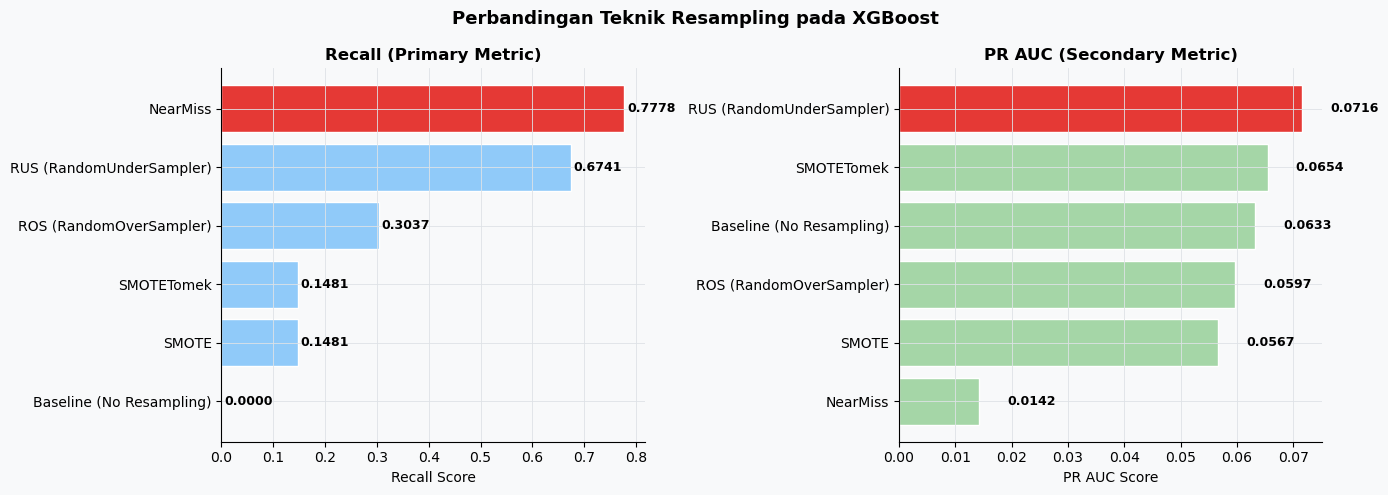

In [26]:
# ─── VISUALISASI RESAMPLING ─────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Perbandingan Teknik Resampling pada XGBoost', fontsize=13, fontweight='bold')

sorted_res   = resampling_df.sort_values('Recall', ascending=True)
colors_res   = ['#e53935' if i == len(sorted_res)-1 else '#90caf9' for i in range(len(sorted_res))]
bars = axes[0].barh(sorted_res.index, sorted_res['Recall'], color=colors_res, edgecolor='white')
axes[0].set_title('Recall (Primary Metric)', fontweight='bold')
axes[0].set_xlabel('Recall Score')
for bar, val in zip(bars, sorted_res['Recall']):
    axes[0].text(val + 0.005, bar.get_y() + bar.get_height()/2,
                 f'{val:.4f}', va='center', fontsize=9, fontweight='bold')

sorted_prauc = resampling_df.sort_values('PR AUC', ascending=True)
colors_prauc = ['#e53935' if i == len(sorted_prauc)-1 else '#a5d6a7' for i in range(len(sorted_prauc))]
bars2 = axes[1].barh(sorted_prauc.index, sorted_prauc['PR AUC'], color=colors_prauc, edgecolor='white')
axes[1].set_title('PR AUC (Secondary Metric)', fontweight='bold')
axes[1].set_xlabel('PR AUC Score')
for bar, val in zip(bars2, sorted_prauc['PR AUC']):
    axes[1].text(val + 0.005, bar.get_y() + bar.get_height()/2,
                 f'{val:.4f}', va='center', fontsize=9, fontweight='bold')

plt.tight_layout()
plt.show()


---
## 🔒 Step 10 · Penalized Model (`class_weight` & `scale_pos_weight`)

> Sebagai alternatif resampling, model dapat diberi **bobot kelas** secara langsung melalui parameter `class_weight='balanced'` (Scikit-learn) atau `scale_pos_weight` (XGBoost). Pendekatan ini tidak mengubah distribusi data, melainkan memberikan penalti lebih besar untuk kesalahan pada kelas minoritas selama pelatihan.

**Keunggulan dibanding resampling:**
- Tidak ada data sintetis yang dibuat (lebih aman untuk beberapa jenis data)
- Lebih cepat secara komputasi
- Dapat dikombinasikan dengan parameter lainnya

**Catatan metodologis:** Logistic Regression dengan `class_weight='balanced'` diikutsertakan sebagai kandidat yang perlu dipertimbangkan karena interpretabilitasnya yang tinggi dan kemampuannya menghasilkan keseimbangan Recall-Precision yang wajar.


In [27]:
# ─── PENALIZED MODEL EXPERIMENT ────────────────────
ratio_neg_pos = (y_train == 0).sum() / (y_train == 1).sum()
print(f"  scale_pos_weight (XGBoost) = {ratio_neg_pos:.2f}")
print()

penalized_models = {
    'Baseline (XGBoost default)': XGBClassifier(
        random_state=RANDOM_STATE, n_jobs=-1, eval_metric='logloss'
    ),
    'XGBoost (scale_pos_weight)': XGBClassifier(
        scale_pos_weight=ratio_neg_pos,
        random_state=RANDOM_STATE, n_jobs=-1, eval_metric='logloss'
    ),
    'Logistic Regression (balanced)': LogisticRegression(
        class_weight='balanced', random_state=RANDOM_STATE, max_iter=1000
    ),  # ← menggunakan preprocessor_lr (OneHotEncoder) saat evaluasi Step 12
    'Decision Tree (balanced)': DecisionTreeClassifier(
        class_weight='balanced', random_state=RANDOM_STATE
    ),
    'Random Forest (balanced)': RandomForestClassifier(
        class_weight='balanced', random_state=RANDOM_STATE, n_jobs=-1
    ),
}

penalized_results = {}

print("=" * 72)
print(f"  {'Model':<36} | {'Recall':>8} | {'Precision':>10} | {'F1':>8} | {'PR AUC':>8}")
print("=" * 72)

for name, model in penalized_models.items():
    model.fit(X_train_pp, y_train)
    y_pred = model.predict(X_test_pp)
    y_prob = model.predict_proba(X_test_pp)[:, 1]

    cm_p    = confusion_matrix(y_test, y_pred)
    tn_p, fp_p, fn_p, tp_p = cm_p.ravel()
    rec     = recall_score(y_test, y_pred)
    prec    = precision_score(y_test, y_pred, zero_division=0)
    f1      = f1_score(y_test, y_pred)
    prauc   = average_precision_score(y_test, y_prob)

    penalized_results[name] = {
        'Recall': rec, 'Precision': prec, 'F1': f1,
        'PR AUC': prauc, 'FP': fp_p, 'FN': fn_p
    }
    print(f"  {name:<36} | {rec:>8.4f} | {prec:>10.4f} | {f1:>8.4f} | {prauc:>8.4f}")

print("=" * 72)

penalized_df = pd.DataFrame(penalized_results).T.sort_values('Recall', ascending=False)
print()
print("🏆 Penalized Model ranking (Recall):")
print(penalized_df.round(4).to_string())


  scale_pos_weight (XGBoost) = 57.76

  Model                                |   Recall |  Precision |       F1 |   PR AUC
  Baseline (XGBoost default)           |   0.0000 |     0.0000 |   0.0000 |   0.0633
  XGBoost (scale_pos_weight)           |   0.2815 |     0.0611 |   0.1004 |   0.0566
  Logistic Regression (balanced)       |   0.7259 |     0.0506 |   0.0945 |   0.1016
  Decision Tree (balanced)             |   0.0593 |     0.0503 |   0.0544 |   0.0192
  Random Forest (balanced)             |   0.0074 |     0.0455 |   0.0127 |   0.0389

🏆 Penalized Model ranking (Recall):
                                Recall  Precision     F1  PR AUC        FP       FN
Logistic Regression (balanced)  0.7259     0.0506 0.0945  0.1016 1840.0000  37.0000
XGBoost (scale_pos_weight)      0.2815     0.0611 0.1004  0.0566  584.0000  97.0000
Decision Tree (balanced)        0.0593     0.0503 0.0544  0.0192  151.0000 127.0000
Random Forest (balanced)        0.0074     0.0455 0.0127  0.0389   21.0000 134.

### Step 10.5 · Perbandingan Baseline vs Resampling vs Penalized

> Ringkasan perbandingan ketiga pendekatan untuk memilih **strategi terbaik** sebelum *hyperparameter tuning*. Setiap pendekatan memiliki trade-off yang perlu dipertimbangkan sesuai kebutuhan bisnis.


  STRATEGI vs STRATEGI — SUMMARY
                                      Recall  Precision     F1  PR AUC        FP       FN
Baseline (XGBoost)                    0.0000     0.0000 0.0000  0.0633    7.0000 135.0000
Best Resampling (NearMiss)            0.7778     0.0142 0.0279  0.0142 7279.0000  30.0000
XGBoost Penalized (scale_pos_weight)  0.2815     0.0611 0.1004  0.0566  584.0000  97.0000
LR Balanced (Logistic Regression)     0.7259     0.0506 0.0945  0.1016 1840.0000  37.0000



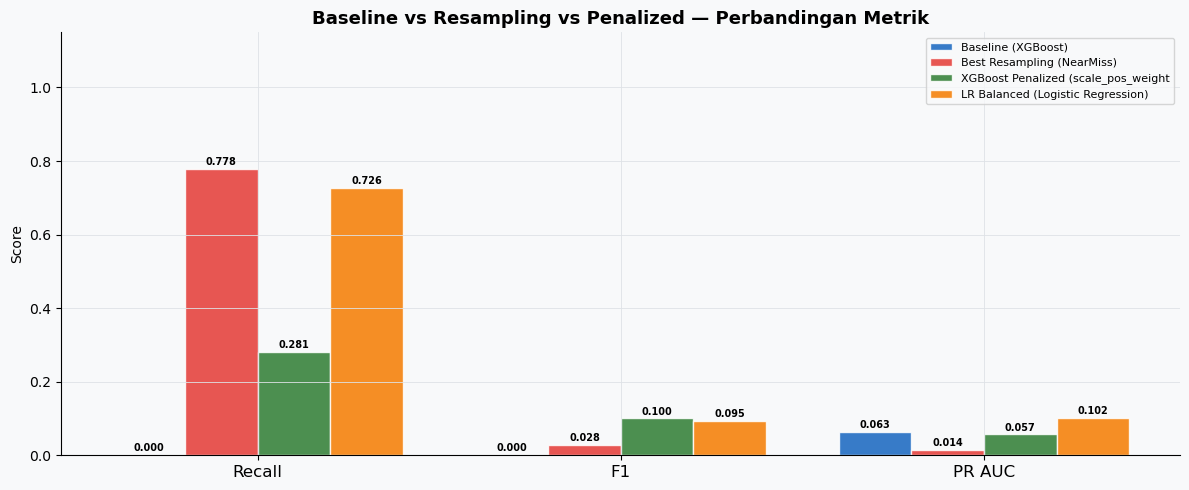

✅ Strategi dengan Recall tertinggi: Best Resampling (NearMiss)
   Recall: 0.7778

⚠️  Catatan: Recall tertinggi belum tentu berarti model terbaik secara keseluruhan.
   Lihat juga F1-score dan PR AUC untuk penilaian yang lebih seimbang.


In [28]:
# ─── KOMPILASI HASIL STRATEGI ────────────────────────
comparison = {
    'Baseline (XGBoost)':            resampling_results['Baseline (No Resampling)'],
    f'Best Resampling ({best_resampler_name.split("(")[0].strip()})':
        resampling_results[best_resampler_name],
    'XGBoost Penalized (scale_pos_weight)':
        penalized_results['XGBoost (scale_pos_weight)'],
    'LR Balanced (Logistic Regression)':
        penalized_results['Logistic Regression (balanced)'],
}

comparison_df = pd.DataFrame(comparison).T

print("=" * 65)
print("  STRATEGI vs STRATEGI — SUMMARY")
print("=" * 65)
print(comparison_df[['Recall', 'Precision', 'F1', 'PR AUC', 'FP', 'FN']].round(4).to_string())
print()

fig, ax = plt.subplots(figsize=(12, 5))
x = np.arange(3)  # Recall, F1, PR AUC
width = 0.2
bar_colors = ['#1565c0', '#e53935', '#2e7d32', '#f57c00']
metric_cols = ['Recall', 'F1', 'PR AUC']

for i, (strat, color) in enumerate(zip(comparison_df.index, bar_colors)):
    vals = [comparison_df.loc[strat, m] for m in metric_cols]
    offset = width * i
    bars = ax.bar(x + offset, vals, width, label=strat[:35], color=color, alpha=0.85, edgecolor='white')
    for bar in bars:
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
                f'{bar.get_height():.3f}', ha='center', va='bottom', fontsize=7, fontweight='bold')

ax.set_xticks(x + width * 1.5)
ax.set_xticklabels(metric_cols, fontsize=12)
ax.set_ylabel('Score')
ax.set_title('Baseline vs Resampling vs Penalized — Perbandingan Metrik', fontweight='bold', fontsize=13)
ax.legend(loc='upper right', fontsize=8)
ax.set_ylim(0, 1.15)
plt.tight_layout()
plt.show()

best_strategy_name = comparison_df['Recall'].idxmax()
print(f"✅ Strategi dengan Recall tertinggi: {best_strategy_name}")
print(f"   Recall: {comparison_df.loc[best_strategy_name, 'Recall']:.4f}")
print()
print("⚠️  Catatan: Recall tertinggi belum tentu berarti model terbaik secara keseluruhan.")
print("   Lihat juga F1-score dan PR AUC untuk penilaian yang lebih seimbang.")


---
## 🔬 Step 11 · Hyperparameter Tuning (RandomizedSearchCV)

> Menggunakan **RandomizedSearchCV** (bukan *GridSearchCV* — lebih efisien untuk ruang parameter besar) dengan `StratifiedKFold(5)` untuk menjaga proporsi kelas. *Primary scoring*: **Recall**.

> Model yang di-*tuning* adalah **XGBoost + teknik resampling terbaik** dari Step 9. Parameter `scale_pos_weight` juga diikutsertakan dalam *search space* agar model dapat menemukan bobot optimal.


In [29]:
# ─── HYPERSPACE XGBoost ────────────────────────────
param_dist_xgb = {
    'n_estimators'     : randint(100, 600),
    'max_depth'        : randint(3, 10),
    'learning_rate'    : uniform(0.01, 0.29),
    'subsample'        : uniform(0.5, 0.5),
    'colsample_bytree' : uniform(0.5, 0.5),
    'min_child_weight' : randint(1, 10),
    'gamma'            : uniform(0, 0.5),
    'scale_pos_weight' : [1, ratio_neg_pos/4, ratio_neg_pos/2,
                          ratio_neg_pos, ratio_neg_pos*1.5],
    'reg_alpha'        : uniform(0, 1),
    'reg_lambda'       : uniform(0.5, 2),
}

cv_strat = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

xgb_base = XGBClassifier(
    random_state=RANDOM_STATE, n_jobs=-1, eval_metric='logloss'
)

rscv = RandomizedSearchCV(
    estimator           = xgb_base,
    param_distributions = param_dist_xgb,
    n_iter              = 50,
    scoring             = 'recall',
    cv                  = cv_strat,
    random_state        = RANDOM_STATE,
    n_jobs              = -1,
    verbose             = 1,
    refit               = True
)

print("⏳ Memulai RandomizedSearchCV (n_iter=50, cv=5) ...")
print("   Primary scoring: Recall")
print()

start = time.time()

# Terapkan resampler terbaik sebelum tuning
best_resampler_obj = resamplers[best_resampler_name]
if best_resampler_obj is not None:
    X_train_res, y_train_res = best_resampler_obj.fit_resample(X_train_pp, y_train)
else:
    X_train_res, y_train_res = X_train_pp, y_train

rscv.fit(X_train_res, y_train_res)
elapsed = time.time() - start

print(f"\n✅ RandomizedSearchCV selesai dalam {elapsed:.1f} detik ({elapsed/60:.1f} menit)")
print()
print("  Best Score (Recall CV):")
print(f"    {rscv.best_score_:.4f}")
print()
print("  Best Parameters:")
for k, v in rscv.best_params_.items():
    print(f"    {k:<22}: {v}")


⏳ Memulai RandomizedSearchCV (n_iter=50, cv=5) ...
   Primary scoring: Recall

Fitting 5 folds for each of 50 candidates, totalling 250 fits

✅ RandomizedSearchCV selesai dalam 23.4 detik (0.4 menit)

  Best Score (Recall CV):
    0.9944

  Best Parameters:
    colsample_bytree      : 0.8401537692938899
    gamma                 : 0.2252496259847715
    learning_rate         : 0.013846838736361293
    max_depth             : 3
    min_child_weight      : 2
    n_estimators          : 364
    reg_alpha             : 0.015966252220214194
    reg_lambda            : 0.961787651244298
    scale_pos_weight      : 57.75555555555555
    subsample             : 0.7200762468698007


---
## 📊 Step 12 · Evaluasi pada Data Test

> Model dievaluasi pada **data test** (data yang belum pernah dilihat model) untuk mengukur kemampuan generalisasi yang sesungguhnya. Lima kandidat model dibandingkan: Baseline, Best Resampling, Penalized/scale_pos_weight, Logistic Regression Balanced, dan Hypertuned.

> **Metrik yang digunakan:** Recall, Precision, F1-Score, PR AUC, ROC AUC, jumlah False Positive (FP), dan False Negative (FN).


In [30]:
# ─── FUNGSI EVALUASI ────────────────────────────────
def evaluate_model(name, model, X_tr, y_tr, X_te, y_te, resampler=None):
    if resampler is not None:
        X_tr_res, y_tr_res = resampler.fit_resample(X_tr, y_tr)
    else:
        X_tr_res, y_tr_res = X_tr, y_tr

    model.fit(X_tr_res, y_tr_res)
    y_pred = model.predict(X_te)
    y_prob = model.predict_proba(X_te)[:, 1]

    cm_e = confusion_matrix(y_te, y_pred)
    tn_e, fp_e, fn_e, tp_e = cm_e.ravel()

    return {
        'Name'      : name,
        'Recall'    : recall_score(y_te, y_pred),
        'Precision' : precision_score(y_te, y_pred, zero_division=0),
        'F1'        : f1_score(y_te, y_pred),
        'PR AUC'    : average_precision_score(y_te, y_prob),
        'ROC AUC'   : roc_auc_score(y_te, y_prob),
        'FP'        : int(fp_e),
        'FN'        : int(fn_e),
        'TP'        : int(tp_e),
        'TN'        : int(tn_e),
        'y_pred'    : y_pred,
        'y_prob'    : y_prob,
    }

# ─── EVALUASI 5 MODEL KANDIDAT FINAL ────────────────
# 1. Baseline XGBoost
res1 = evaluate_model(
    '1. Baseline XGBoost', make_xgb(),
    X_train_pp, y_train, X_test_pp, y_test
)

# 2. XGBoost + Resampling terbaik
res2 = evaluate_model(
    f'2. XGBoost + {best_resampler_name.split("(")[0].strip()}', make_xgb(),
    X_train_pp, y_train, X_test_pp, y_test,
    resampler=resamplers[best_resampler_name]
)

# 3. XGBoost Penalized (scale_pos_weight)
xgb_penalized = XGBClassifier(
    scale_pos_weight=ratio_neg_pos,
    random_state=RANDOM_STATE, n_jobs=-1, eval_metric='logloss'
)
res3 = evaluate_model(
    '3. XGBoost Penalized (scale_pos_weight)', xgb_penalized,
    X_train_pp, y_train, X_test_pp, y_test
)

# 4. Logistic Regression Balanced
# Menggunakan preprocessor_lr (OneHotEncoder) khusus untuk LR
# bukan OrdinalEncoder yang digunakan untuk model tree-based
lr_balanced = LogisticRegression(
    class_weight='balanced', random_state=RANDOM_STATE, max_iter=1000
)
res4 = evaluate_model(
    '4. Logistic Regression Balanced', lr_balanced,
    X_train_pp_lr, y_train, X_test_pp_lr, y_test
)
lr_balanced.fit(X_train_pp_lr, y_train)

y_pred_lr = lr_balanced.predict(X_test_pp_lr)
y_prob_lr = lr_balanced.predict_proba(X_test_pp_lr)[:, 1]

cm_lr = confusion_matrix(y_test, y_pred_lr)
tn, fp, fn, tp = cm_lr.ravel()

print("Confusion Matrix:")
print(cm_lr)
print()

print("Classification Report:")
print(classification_report(y_test, y_pred_lr, target_names=['No Claim', 'Claim']))
print()

print("Recall      :", recall_score(y_test, y_pred_lr))
print("Precision   :", precision_score(y_test, y_pred_lr, zero_division=0))
print("F1-Score    :", f1_score(y_test, y_pred_lr))
print("PR AUC      :", average_precision_score(y_test, y_prob_lr))
print("ROC AUC     :", roc_auc_score(y_test, y_prob_lr))
print("False Positive:", fp)
print("False Negative:", fn)

# 5. XGBoost Hypertuned (best params dari RandomizedSearchCV)
xgb_tuned = XGBClassifier(
    **rscv.best_params_,
    random_state=RANDOM_STATE, n_jobs=-1, eval_metric='logloss'
)
res5 = evaluate_model(
    '5. XGBoost Hypertuned', xgb_tuned,
    X_train_res, y_train_res, X_test_pp, y_test
)

all_results = [res1, res2, res3, res4, res5]
results_df  = pd.DataFrame([
    {k: v for k, v in r.items() if k not in ['y_pred', 'y_prob']}
    for r in all_results
]).set_index('Name')

print("=" * 90)
print("  EVALUASI FINAL — DATA TEST (UNSEEN DATA)")
print("=" * 90)
print(results_df[['Recall', 'Precision', 'F1', 'PR AUC', 'ROC AUC', 'FP', 'FN']].round(4).to_string())
print()
print("📌 Keterangan:")
print("   FP = False Positive (prediksi klaim, padahal tidak klaim) → biaya verifikasi sia-sia")
print("   FN = False Negative (prediksi tidak klaim, padahal klaim) → ⚠️ klaim terlewat, lebih mahal!")


Confusion Matrix:
[[6145 1653]
 [  33  102]]

Classification Report:
              precision    recall  f1-score   support

    No Claim       0.99      0.79      0.88      7798
       Claim       0.06      0.76      0.11       135

    accuracy                           0.79      7933
   macro avg       0.53      0.77      0.49      7933
weighted avg       0.98      0.79      0.87      7933


Recall      : 0.7555555555555555
Precision   : 0.05811965811965812
F1-Score    : 0.10793650793650794
PR AUC      : 0.10075275862318112
ROC AUC     : 0.8111472077360766
False Positive: 1653
False Negative: 33
  EVALUASI FINAL — DATA TEST (UNSEEN DATA)
                                         Recall  Precision     F1  PR AUC  ROC AUC    FP   FN
Name                                                                                         
1. Baseline XGBoost                      0.0000     0.0000 0.0000  0.0633   0.7588     7  135
2. XGBoost + NearMiss                    0.7778     0.0142 0.0279  0.0

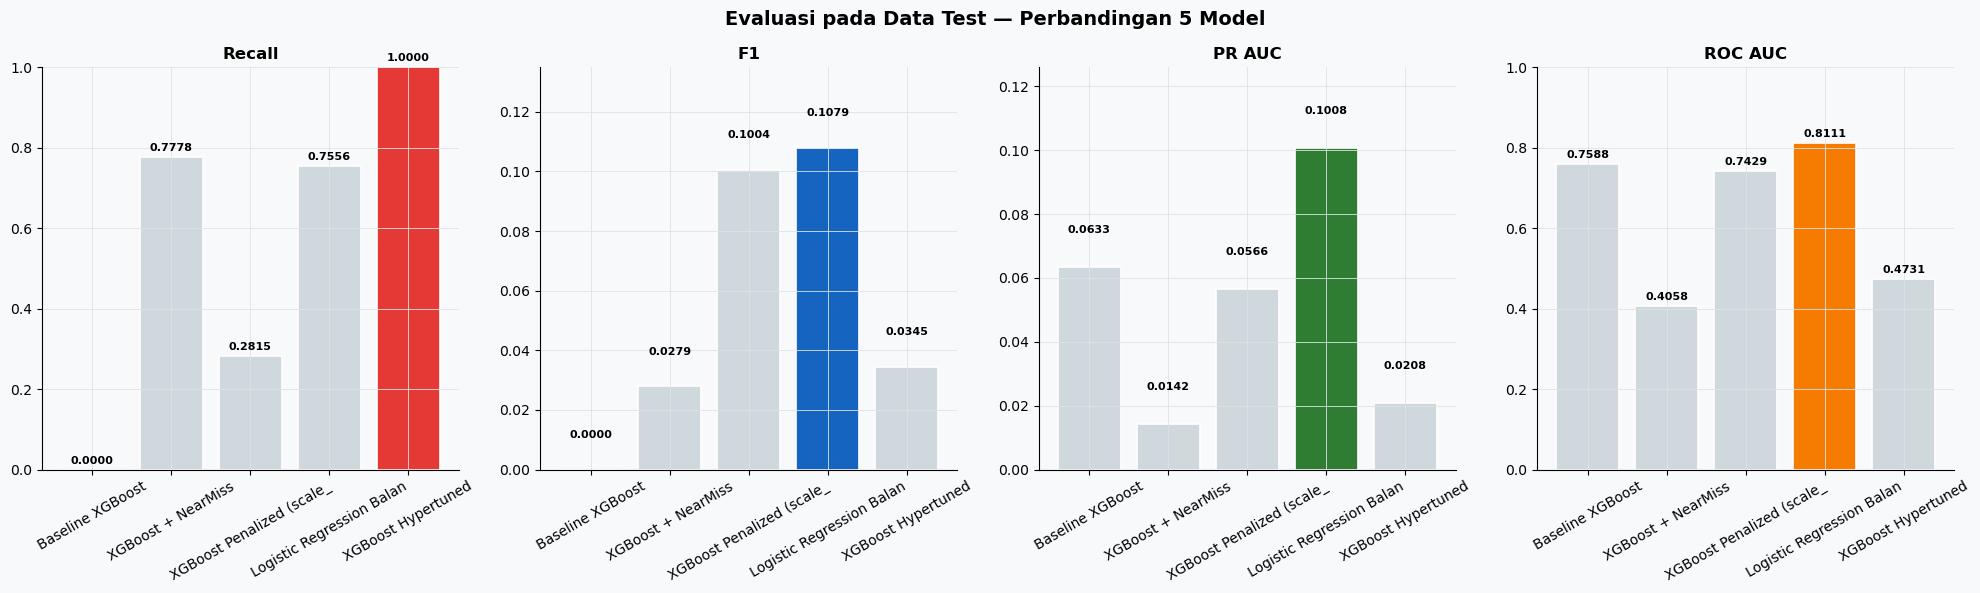

In [31]:
# ─── VISUALISASI PERBANDINGAN TEST ─────────────────
fig, axes = plt.subplots(1, 4, figsize=(20, 6))
fig.suptitle('Evaluasi pada Data Test — Perbandingan 5 Model', fontsize=14, fontweight='bold')

metrics_vis = ['Recall', 'F1', 'PR AUC', 'ROC AUC']
colors_vis  = ['#e53935', '#1565c0', '#2e7d32', '#f57c00']
labels = [r['Name'].split('.')[1].strip()[:25] for r in all_results]
values_all = [[r[m] for r in all_results] for m in metrics_vis]

for i, (metric, vals, color) in enumerate(zip(metrics_vis, values_all, colors_vis)):
    bar_colors_i = [color if v == max(vals) else '#cfd8dc' for v in vals]
    bars = axes[i].bar(labels, vals, color=bar_colors_i, edgecolor='white', linewidth=1.2)
    axes[i].set_title(f'{metric}', fontweight='bold', fontsize=12)
    axes[i].set_ylim(0, min(1.0, max(vals) * 1.25))
    axes[i].tick_params(axis='x', rotation=30)
    for bar, val in zip(bars, vals):
        axes[i].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
                     f'{val:.4f}', ha='center', va='bottom', fontsize=8, fontweight='bold')

plt.tight_layout()
plt.show()


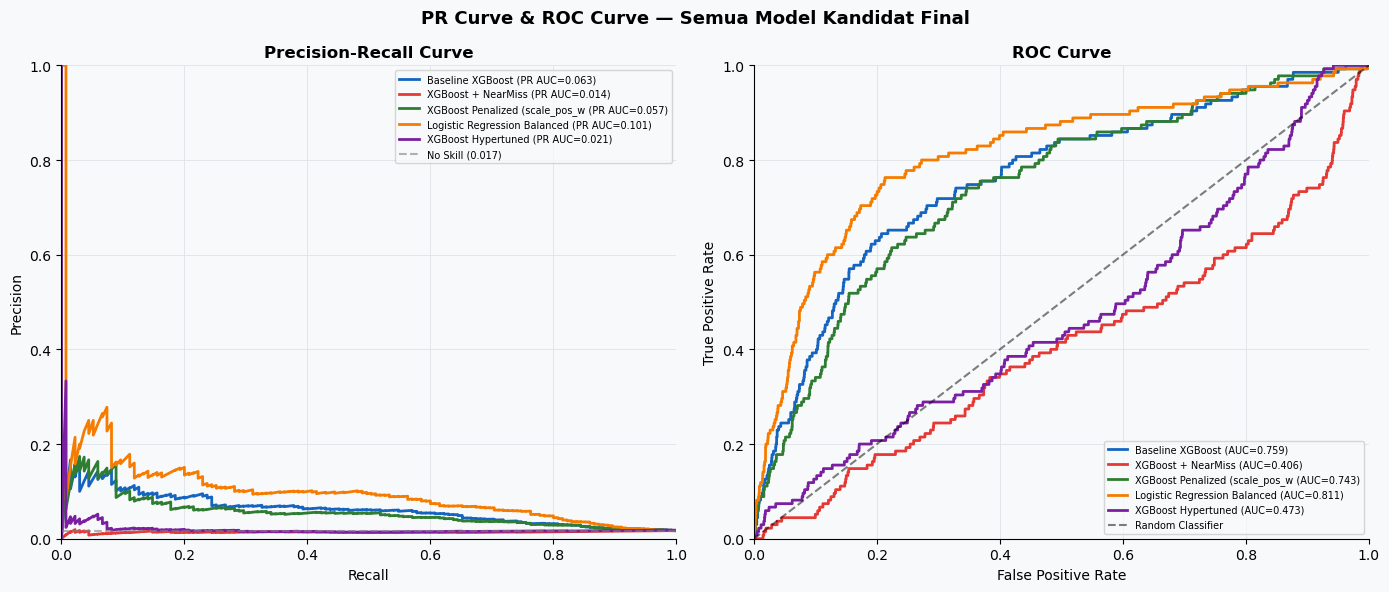

In [32]:
# ─── PR CURVE & ROC CURVE ──────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle('PR Curve & ROC Curve — Semua Model Kandidat Final', fontsize=13, fontweight='bold')

curve_colors = ['#1565c0', '#e53935', '#2e7d32', '#f57c00', '#7b1fa2']

for res, color in zip(all_results, curve_colors):
    label_short = res['Name'].split('.')[1].strip()[:30]
    prec_arr, rec_arr, _ = precision_recall_curve(y_test, res['y_prob'])
    axes[0].plot(rec_arr, prec_arr, color=color, linewidth=2,
                 label=f"{label_short} (PR AUC={res['PR AUC']:.3f})")
    fpr, tpr, _ = roc_curve(y_test, res['y_prob'])
    axes[1].plot(fpr, tpr, color=color, linewidth=2,
                 label=f"{label_short} (AUC={res['ROC AUC']:.3f})")

no_skill = y_test.mean()
axes[0].axhline(y=no_skill, color='gray', linestyle='--', alpha=0.6, label=f'No Skill ({no_skill:.3f})')
axes[0].set_xlabel('Recall');  axes[0].set_ylabel('Precision')
axes[0].set_title('Precision-Recall Curve', fontweight='bold')
axes[0].legend(fontsize=7);  axes[0].set_xlim([0, 1]);  axes[0].set_ylim([0, 1])

axes[1].plot([0,1],[0,1], 'k--', alpha=0.5, label='Random Classifier')
axes[1].set_xlabel('False Positive Rate'); axes[1].set_ylabel('True Positive Rate')
axes[1].set_title('ROC Curve', fontweight='bold')
axes[1].legend(fontsize=7);  axes[1].set_xlim([0, 1]);  axes[1].set_ylim([0, 1])

plt.tight_layout()
plt.show()


---
## 🔎 Step 13 · Model Checking — Cost-Benefit Analysis, Threshold Tuning & Interpretability

### 13a. Asumsi Biaya Bisnis

Untuk mengevaluasi model secara finansial, digunakan asumsi biaya berikut:

| Kategori | Asumsi Biaya | Keterangan |
|---|---|---|
| **False Negative (FN)** | **5.000 unit** | Klaim aktual tidak terdeteksi → estimasi kerugian rata-rata per klaim |
| **False Positive (FP)** | **50 unit** | Verifikasi tambahan yang tidak perlu → biaya operasional per kasus |

> Asumsi: biaya FN = 100× biaya FP, mencerminkan bahwa melewatkan klaim jauh lebih mahal daripada melakukan verifikasi yang sia-sia. Nilai dapat disesuaikan dengan data aktual perusahaan.


  COST-BENEFIT ANALYSIS — SEMUA MODEL KANDIDAT FINAL
  Asumsi biaya per FN (klaim tidak terdeteksi) : 5,000 unit
  Asumsi biaya per FP (verifikasi sia-sia)     : 50 unit

  Model                                      |    FN |     FP |    Cost FN |   Cost FP |   Total Cost
----------------------------------------------------------------------------------------------------
  1. Baseline XGBoost                        |   135 |      7 |    675,000 |       350 |      675,350
  2. XGBoost + NearMiss                      |    30 |   7279 |    150,000 |   363,950 |      513,950
  3. XGBoost Penalized (scale_pos_weight)    |    97 |    584 |    485,000 |    29,200 |      514,200
  4. Logistic Regression Balanced            |    33 |   1653 |    165,000 |    82,650 |      247,650
  5. XGBoost Hypertuned                      |     0 |   7545 |          0 |   377,250 |      377,250

✅ Model paling efisien (Total Cost terendah): 4. Logistic Regression Balanced
   Total Cost: 247,650 unit



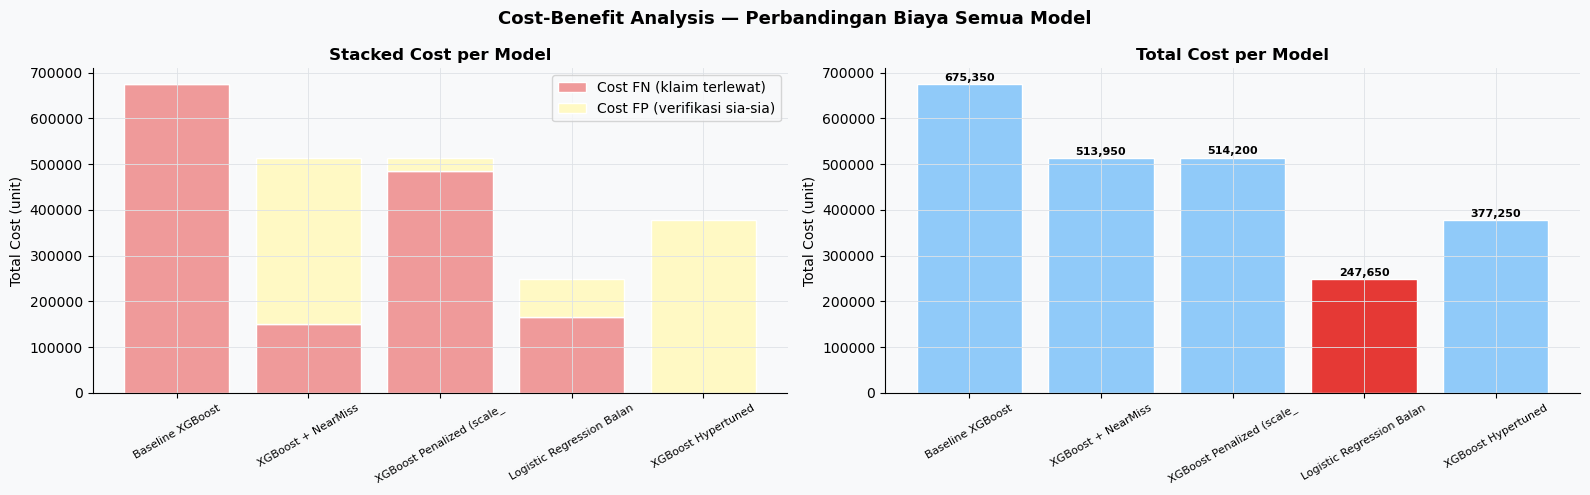

In [33]:
# ─── 13a. COST-BENEFIT ANALYSIS — SEMUA MODEL ────────
avg_claim_value = 5000   # estimasi rata-rata kerugian per FN (dalam satuan unit)
fp_cost         = 50     # biaya verifikasi sia-sia per FP

print("=" * 80)
print("  COST-BENEFIT ANALYSIS — SEMUA MODEL KANDIDAT FINAL")
print("=" * 80)
print(f"  Asumsi biaya per FN (klaim tidak terdeteksi) : {avg_claim_value:,} unit")
print(f"  Asumsi biaya per FP (verifikasi sia-sia)     : {fp_cost:,} unit")
print()
print(f"  {'Model':<42} | {'FN':>5} | {'FP':>6} | {'Cost FN':>10} | {'Cost FP':>9} | {'Total Cost':>12}")
print("-" * 100)

cost_results = []
for r in all_results:
    fn_c = r['FN'] * avg_claim_value
    fp_c = r['FP'] * fp_cost
    total_c = fn_c + fp_c
    cost_results.append({
        'Model': r['Name'],
        'FN': r['FN'], 'FP': r['FP'],
        'Cost FN': fn_c, 'Cost FP': fp_c, 'Total Cost': total_c,
        'Recall': r['Recall'], 'F1': r['F1']
    })
    print(f"  {r['Name']:<42} | {r['FN']:>5} | {r['FP']:>6} | {fn_c:>10,} | {fp_c:>9,} | {total_c:>12,}")

cost_df = pd.DataFrame(cost_results).sort_values('Total Cost')
print()
print(f"✅ Model paling efisien (Total Cost terendah): {cost_df.iloc[0]['Model']}")
print(f"   Total Cost: {cost_df.iloc[0]['Total Cost']:,} unit")
print()

# Visualisasi total cost
fig, axes = plt.subplots(1, 2, figsize=(16, 5))
fig.suptitle('Cost-Benefit Analysis — Perbandingan Biaya Semua Model', fontweight='bold', fontsize=13)

labels_cb   = [r['Name'].split('.')[1].strip()[:25] for r in all_results]
total_costs = [r['Total Cost'] for r in cost_results]
fp_costs    = [r['Cost FP'] for r in cost_results]
fn_costs    = [r['Cost FN'] for r in cost_results]

x_pos = np.arange(len(labels_cb))
axes[0].bar(x_pos, fn_costs, color='#ef9a9a', label='Cost FN (klaim terlewat)', edgecolor='white')
axes[0].bar(x_pos, fp_costs, bottom=fn_costs, color='#fff9c4', label='Cost FP (verifikasi sia-sia)', edgecolor='white')
axes[0].set_xticks(x_pos)
axes[0].set_xticklabels(labels_cb, rotation=30, fontsize=8)
axes[0].set_title('Stacked Cost per Model', fontweight='bold')
axes[0].set_ylabel('Total Cost (unit)')
axes[0].legend()

axes[1].bar(labels_cb, total_costs,
            color=['#e53935' if v == min(total_costs) else '#90caf9' for v in total_costs],
            edgecolor='white')
axes[1].set_xticklabels(labels_cb, rotation=30, fontsize=8)
axes[1].set_title('Total Cost per Model', fontweight='bold')
axes[1].set_ylabel('Total Cost (unit)')
for i, val in enumerate(total_costs):
    axes[1].text(i, val + max(total_costs)*0.01, f'{val:,}', ha='center', fontsize=8, fontweight='bold')

plt.tight_layout()
plt.show()


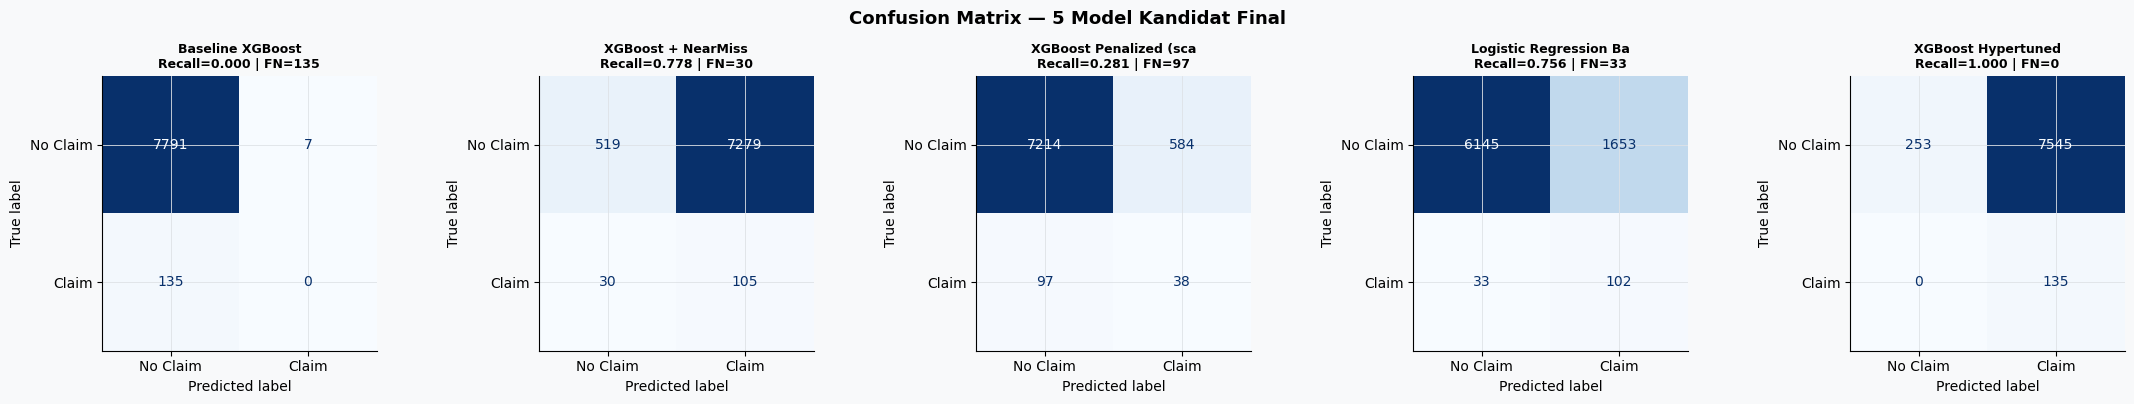

In [34]:
# ─── 13b. CONFUSION MATRIX — SEMUA MODEL ─────────────
fig, axes = plt.subplots(1, 5, figsize=(22, 4))
fig.suptitle('Confusion Matrix — 5 Model Kandidat Final', fontsize=13, fontweight='bold')

for ax, res in zip(axes, all_results):
    cm_vis = confusion_matrix(y_test, res['y_pred'])
    disp = ConfusionMatrixDisplay(confusion_matrix=cm_vis, display_labels=['No Claim', 'Claim'])
    disp.plot(ax=ax, colorbar=False, cmap='Blues')
    ax.set_title(f"{res['Name'].split('.')[1].strip()[:22]}\n"
                 f"Recall={res['Recall']:.3f} | FN={res['FN']}", fontsize=9, fontweight='bold')

plt.tight_layout()
plt.show()


In [35]:
# ─── CLASSIFICATION REPORT — SEMUA MODEL ────────────
for res in all_results:
    print("=" * 60)
    print(f"  {res['Name']}")
    print("=" * 60)
    print(classification_report(y_test, res['y_pred'],
                                 target_names=['No Claim (0)', 'Claim (1)']))


  1. Baseline XGBoost
              precision    recall  f1-score   support

No Claim (0)       0.98      1.00      0.99      7798
   Claim (1)       0.00      0.00      0.00       135

    accuracy                           0.98      7933
   macro avg       0.49      0.50      0.50      7933
weighted avg       0.97      0.98      0.97      7933

  2. XGBoost + NearMiss
              precision    recall  f1-score   support

No Claim (0)       0.95      0.07      0.12      7798
   Claim (1)       0.01      0.78      0.03       135

    accuracy                           0.08      7933
   macro avg       0.48      0.42      0.08      7933
weighted avg       0.93      0.08      0.12      7933

  3. XGBoost Penalized (scale_pos_weight)
              precision    recall  f1-score   support

No Claim (0)       0.99      0.93      0.95      7798
   Claim (1)       0.06      0.28      0.10       135

    accuracy                           0.91      7933
   macro avg       0.52      0.60      0

---
## 🎛️ Step 13c · Threshold Tuning

> Secara *default*, model menggunakan threshold **0.5** untuk mengklasifikasikan prediksi. Namun, pada data yang sangat *imbalanced*, threshold 0.5 sering kali terlalu tinggi untuk kelas minoritas, sehingga banyak kasus klaim yang tidak terdeteksi.

**Mengapa Threshold Tuning Penting?**
- Threshold adalah nilai batas probabilitas yang digunakan untuk memutuskan prediksi kelas
- **Menurunkan** threshold → Recall meningkat (lebih banyak klaim terdeteksi), tetapi Precision menurun dan **FP bertambah** (lebih banyak verifikasi sia-sia)
- **Menaikkan** threshold → Precision meningkat dan **FP berkurang**, tetapi Recall menurun dan FN bertambah (lebih banyak klaim yang terlewat)
- Jika FP terlalu besar, threshold perlu **dinaikkan** sambil menjaga Recall tetap pada level minimum yang dapat diterima secara bisnis
- Threshold tuning adalah pencarian **titik optimal** di antara lima dimensi: Recall, Precision, FP, FN, dan Total Cost — tidak ada solusi tunggal yang sempurna; pilihannya bergantung pada prioritas bisnis

Model yang digunakan untuk threshold tuning adalah **2–3 kandidat terkuat** berdasarkan PR AUC.


In [36]:
# ─── THRESHOLD TUNING — LOGISTIC REGRESSION BALANCED ───

thresholds_to_test = [0.10, 0.15, 0.20, 0.25, 0.30, 0.35, 0.40, 0.45, 0.50, 0.55, 0.60]

avg_claim_value = 5000
fp_cost = 50

threshold_results = []

print("=" * 90)
print("THRESHOLD TUNING — LOGISTIC REGRESSION BALANCED")
print("=" * 90)
print(f"{'Threshold':>10} | {'Recall':>8} | {'Precision':>10} | {'F1':>8} | {'FP':>6} | {'FN':>5} | {'Total Cost':>12}")
print("-" * 90)

for thr in thresholds_to_test:
    y_pred_thr = (y_prob_lr >= thr).astype(int)

    cm_thr = confusion_matrix(y_test, y_pred_thr)
    tn, fp, fn, tp = cm_thr.ravel()

    rec = recall_score(y_test, y_pred_thr)
    prec = precision_score(y_test, y_pred_thr, zero_division=0)
    f1 = f1_score(y_test, y_pred_thr)
    total_cost = fn * avg_claim_value + fp * fp_cost

    threshold_results.append({
        'Threshold': thr,
        'Recall': rec,
        'Precision': prec,
        'F1': f1,
        'FP': fp,
        'FN': fn,
        'Total Cost': total_cost
    })

    print(f"{thr:>10.2f} | {rec:>8.4f} | {prec:>10.4f} | {f1:>8.4f} | {fp:>6} | {fn:>5} | {total_cost:>12,}")

threshold_df = pd.DataFrame(threshold_results)

best_threshold_row = threshold_df.sort_values('Total Cost').iloc[0]
best_threshold = best_threshold_row['Threshold']

print()
print("Threshold terbaik berdasarkan total cost:")
print(best_threshold_row)

print()
print(f"Best Threshold: {best_threshold:.2f}")


THRESHOLD TUNING — LOGISTIC REGRESSION BALANCED
 Threshold |   Recall |  Precision |       F1 |     FP |    FN |   Total Cost
------------------------------------------------------------------------------------------
      0.10 |   0.9481 |     0.0205 |   0.0402 |   6105 |     7 |      340,250
      0.15 |   0.9111 |     0.0230 |   0.0449 |   5218 |    12 |      320,900
      0.20 |   0.8963 |     0.0262 |   0.0508 |   4504 |    14 |      295,200
      0.25 |   0.8815 |     0.0294 |   0.0568 |   3935 |    16 |      276,750
      0.30 |   0.8593 |     0.0339 |   0.0652 |   3305 |    19 |      260,250
      0.35 |   0.8222 |     0.0384 |   0.0735 |   2776 |    24 |      258,800
      0.40 |   0.8074 |     0.0446 |   0.0845 |   2337 |    26 |      246,850
      0.45 |   0.7778 |     0.0510 |   0.0958 |   1953 |    30 |      247,650
      0.50 |   0.7556 |     0.0581 |   0.1079 |   1653 |    33 |      247,650
      0.55 |   0.7037 |     0.0632 |   0.1159 |   1409 |    40 |      270,450
   

In [37]:
# Prediksi final menggunakan threshold terbaik
y_pred_final = (y_prob_lr >= best_threshold).astype(int)

cm_final = confusion_matrix(y_test, y_pred_final)
tn, fp, fn, tp = cm_final.ravel()

print("=" * 90)
print("EVALUASI FINAL — LOGISTIC REGRESSION BALANCED")
print("=" * 90)

print("Confusion Matrix:")
print(cm_final)
print()

print("Classification Report:")
print(classification_report(y_test, y_pred_final, target_names=['No Claim', 'Claim']))
print()

print("Recall      :", recall_score(y_test, y_pred_final))
print("Precision   :", precision_score(y_test, y_pred_final, zero_division=0))
print("F1-Score    :", f1_score(y_test, y_pred_final))
print("PR AUC      :", average_precision_score(y_test, y_prob_lr))
print("ROC AUC     :", roc_auc_score(y_test, y_prob_lr))
print("False Positive:", fp)
print("False Negative:", fn)

total_cost_final = fn * avg_claim_value + fp * fp_cost
print("Total Cost  :", total_cost_final)

EVALUASI FINAL — LOGISTIC REGRESSION BALANCED
Confusion Matrix:
[[5461 2337]
 [  26  109]]

Classification Report:
              precision    recall  f1-score   support

    No Claim       1.00      0.70      0.82      7798
       Claim       0.04      0.81      0.08       135

    accuracy                           0.70      7933
   macro avg       0.52      0.75      0.45      7933
weighted avg       0.98      0.70      0.81      7933


Recall      : 0.8074074074074075
Precision   : 0.04456255110384301
F1-Score    : 0.08446338628438589
PR AUC      : 0.10075275862318112
ROC AUC     : 0.8111472077360766
False Positive: 2337
False Negative: 26
Total Cost  : 246850


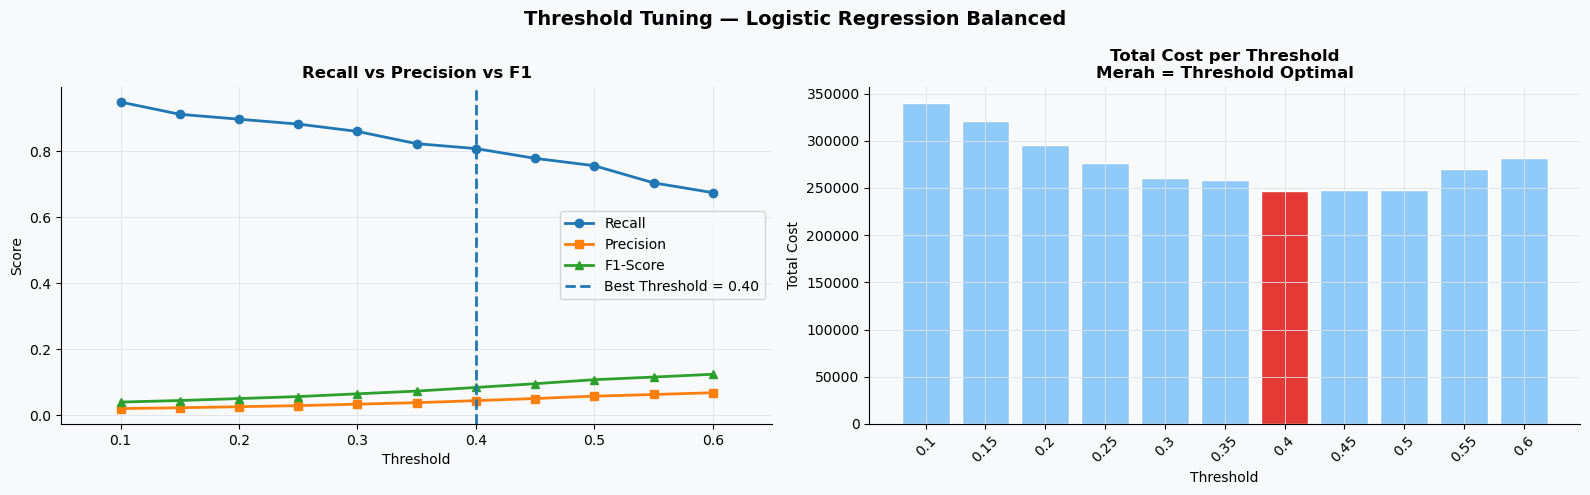

THRESHOLD TERBAIK — LOGISTIC REGRESSION BALANCED
Threshold optimal : 0.40
Recall            : 0.8074
Precision         : 0.0446
F1-Score          : 0.0845
FP                : 2337
FN                : 26
Total Cost        : 246,850 unit


In [38]:
# ─── VISUALISASI THRESHOLD TUNING — LOGISTIC REGRESSION BALANCED ───

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

fig.suptitle(
    'Threshold Tuning — Logistic Regression Balanced',
    fontsize=14,
    fontweight='bold'
)

# ─── Recall vs Precision vs F1 ───
axes[0].plot(
    threshold_df['Threshold'],
    threshold_df['Recall'],
    marker='o',
    linewidth=2,
    label='Recall'
)

axes[0].plot(
    threshold_df['Threshold'],
    threshold_df['Precision'],
    marker='s',
    linewidth=2,
    label='Precision'
)

axes[0].plot(
    threshold_df['Threshold'],
    threshold_df['F1'],
    marker='^',
    linewidth=2,
    label='F1-Score'
)

axes[0].axvline(
    best_threshold,
    linestyle='--',
    linewidth=2,
    label=f'Best Threshold = {best_threshold:.2f}'
)

axes[0].set_title(
    'Recall vs Precision vs F1',
    fontweight='bold'
)

axes[0].set_xlabel('Threshold')
axes[0].set_ylabel('Score')
axes[0].legend()
axes[0].set_xlim([0.05, 0.65])

# ─── Total Cost per Threshold ───
best_thr_idx = threshold_df['Total Cost'].idxmin()

bar_colors = [
    '#e53935' if i == best_thr_idx else '#90caf9'
    for i in threshold_df.index
]

axes[1].bar(
    threshold_df['Threshold'].astype(str),
    threshold_df['Total Cost'],
    color=bar_colors,
    edgecolor='white'
)

axes[1].set_title(
    'Total Cost per Threshold\nMerah = Threshold Optimal',
    fontweight='bold'
)

axes[1].set_xlabel('Threshold')
axes[1].set_ylabel('Total Cost')
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

# ─── THRESHOLD TERBAIK LOGISTIC REGRESSION BALANCED ───

best_row = threshold_df.loc[threshold_df['Total Cost'].idxmin()]

print("=" * 70)
print("THRESHOLD TERBAIK — LOGISTIC REGRESSION BALANCED")
print("=" * 70)
print(f"Threshold optimal : {best_row['Threshold']:.2f}")
print(f"Recall            : {best_row['Recall']:.4f}")
print(f"Precision         : {best_row['Precision']:.4f}")
print(f"F1-Score          : {best_row['F1']:.4f}")
print(f"FP                : {int(best_row['FP'])}")
print(f"FN                : {int(best_row['FN'])}")
print(f"Total Cost        : {int(best_row['Total Cost']):,} unit")


In [39]:
# ─── 13d. FEATURE IMPORTANCE — LOGISTIC REGRESSION COEFFICIENT ───

# Ambil nama fitur setelah preprocessing OneHotEncoder
feature_names_lr = preprocessor_lr.get_feature_names_out()

# Ambil coefficient dari Logistic Regression
coef_df = pd.DataFrame({
    'Feature': feature_names_lr,
    'Coefficient': lr_balanced.coef_[0]
})

# Nilai absolut coefficient untuk melihat pengaruh terbesar
coef_df['Abs_Coefficient'] = coef_df['Coefficient'].abs()

# Urutkan dari fitur paling berpengaruh
coef_df_sorted = coef_df.sort_values('Abs_Coefficient', ascending=False)

print("=" * 90)
print("TOP 20 FITUR PALING BERPENGARUH — LOGISTIC REGRESSION BALANCED")
print("=" * 90)

display(coef_df_sorted.head(20))


TOP 20 FITUR PALING BERPENGARUH — LOGISTIC REGRESSION BALANCED


,Feature,Coefficient,Abs_Coefficient
82,cat__Destination_COSTA RICA,4.1690,4.1690
49,cat__Product Name_Spouse or Parents Comprehens...,2.6513,2.6513
179,cat__Destination_UNITED ARAB EMIRATES,2.4765,2.4765
105,cat__Destination_HONG KONG,2.3136,2.3136
9,cat__Agency_ART,-2.2596,2.2596
15,cat__Agency_EPX,2.2291,2.2291
10,cat__Agency_C2B,2.2001,2.2001
150,cat__Destination_PHILIPPINES,2.1688,2.1688
164,cat__Destination_SPAIN,2.1505,2.1505
109,cat__Destination_INDONESIA,1.9900,1.9900


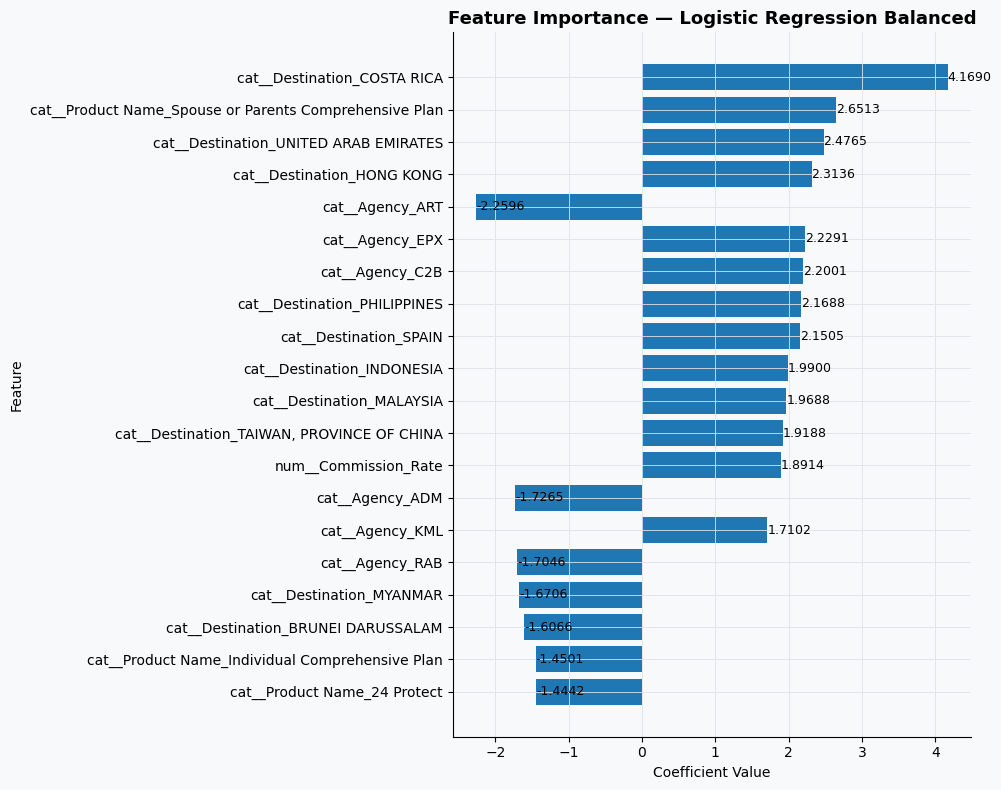

In [40]:
# Visualisasi Top 20 Feature Importance Logistic Regression
top20_coef = coef_df_sorted.head(20).sort_values('Abs_Coefficient', ascending=True)

fig, ax = plt.subplots(figsize=(10, 8))

bars = ax.barh(
    top20_coef['Feature'],
    top20_coef['Coefficient']
)

ax.set_title(
    'Feature Importance — Logistic Regression Balanced',
    fontweight='bold',
    fontsize=13
)

ax.set_xlabel('Coefficient Value')
ax.set_ylabel('Feature')

for bar, val in zip(bars, top20_coef['Coefficient']):
    ax.text(
        val,
        bar.get_y() + bar.get_height() / 2,
        f'{val:.4f}',
        va='center',
        fontsize=9
    )

plt.tight_layout()
plt.show()

In [41]:
print("Top 5 fitur paling berpengaruh pada Logistic Regression Balanced:")

top5_lr = coef_df_sorted.head(5)

for _, row in top5_lr.iterrows():
    direction = "meningkatkan kemungkinan Claim" if row['Coefficient'] > 0 else "menurunkan kemungkinan Claim"
    print(f"→ {row['Feature']:<50} : {row['Coefficient']:.4f} ({direction})")

Top 5 fitur paling berpengaruh pada Logistic Regression Balanced:
→ cat__Destination_COSTA RICA                        : 4.1690 (meningkatkan kemungkinan Claim)
→ cat__Product Name_Spouse or Parents Comprehensive Plan : 2.6513 (meningkatkan kemungkinan Claim)
→ cat__Destination_UNITED ARAB EMIRATES              : 2.4765 (meningkatkan kemungkinan Claim)
→ cat__Destination_HONG KONG                         : 2.3136 (meningkatkan kemungkinan Claim)
→ cat__Agency_ART                                    : -2.2596 (menurunkan kemungkinan Claim)


In [42]:
!pip install shap

SHAP Summary Plot — Logistic Regression Balanced
Jumlah sampel test yang digunakan: 500


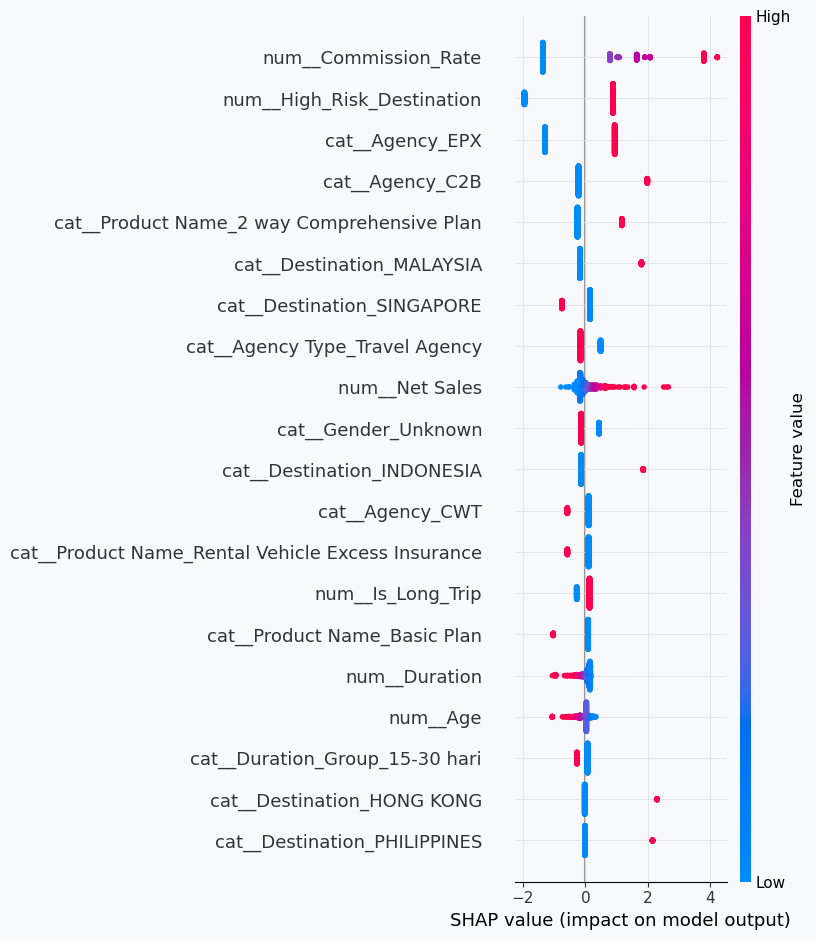

In [43]:
# ─── OPTIONAL: SHAP — LOGISTIC REGRESSION BALANCED ───

try:

    # Ambil nama fitur dari preprocessor Logistic Regression
    feature_names_lr = preprocessor_lr.get_feature_names_out()

    # Ambil sample data agar SHAP tidak terlalu berat
    n_background = min(100, X_train_pp_lr.shape[0])
    n_sample = min(500, X_test_pp_lr.shape[0])

    X_train_sample = X_train_pp_lr[:n_background]
    X_test_sample = X_test_pp_lr[:n_sample]

    # Jika sparse matrix, ubah ke dense array
    if sparse.issparse(X_train_sample):
        X_train_sample = X_train_sample.toarray()

    if sparse.issparse(X_test_sample):
        X_test_sample = X_test_sample.toarray()

    # SHAP untuk Logistic Regression
    explainer = shap.LinearExplainer(
        lr_balanced,
        X_train_sample
    )

    shap_values = explainer.shap_values(X_test_sample)

    print("SHAP Summary Plot — Logistic Regression Balanced")
    print(f"Jumlah sampel test yang digunakan: {n_sample}")

    shap.summary_plot(
        shap_values,
        X_test_sample,
        feature_names=feature_names_lr,
        show=True
    )

except ImportError:
    print("SHAP tidak terinstall.")
    print("Jalankan: pip install shap")
    print("Kemudian re-run cell ini untuk mendapatkan interpretasi SHAP.")

except NameError as e:
    print("Ada variabel yang belum dibuat:", e)
    print("Pastikan lr_balanced, preprocessor_lr, X_train_pp_lr, dan X_test_pp_lr sudah dijalankan terlebih dahulu.")

---
## 📝 Step 14 · Kesimpulan & Rekomendasi

### 14a. Rangkuman Kondisi Data
Dataset *travel insurance* ini memiliki beberapa karakteristik penting yang memengaruhi strategi pemodelan:

1. **Imbalance sangat ekstrem**: Kelas `Yes` (klaim) hanya **~1,70%** dari 39.661 data setelah deduplikasi (675 kasus klaim dari total). Rasio imbalance ~1:58, jauh melampaui ambang batas umum 1:10.
2. **Missing value tinggi**: Kolom `Gender` memiliki **~69,76% missing value** — terlalu banyak untuk diisi secara bermakna, sehingga diperlakukan sebagai kategori `Unknown`.
3. **Outlier pada numerik**: Nilai `Duration` negatif dan `Age` ekstrem (>100 atau <18) sudah dikoreksi melalui *clipping*.
4. **Accuracy TIDAK cocok** sebagai metrik utama: model naif yang selalu prediksi `No` akan mencapai ~98,30% accuracy tetapi tidak mendeteksi satu pun klaim.

### 14b. Pemilihan Model Final

Tabel di bawah ini merangkum semua model kandidat final beserta trade-off masing-masing:


In [44]:
# ─── TABEL PERBANDINGAN FINAL LENGKAP ─────────────────
print("=" * 105)
print("  TABEL EVALUASI FINAL — PERBANDINGAN SEMUA KANDIDAT MODEL")
print("=" * 105)
print(f"  {'Model':<42} | {'Recall':>7} | {'Precision':>10} | {'F1':>7} | {'PR AUC':>8} | {'ROC AUC':>9} | {'FP':>6} | {'FN':>5}")
print("-" * 105)

for res in all_results:
    print(f"  {res['Name']:<42} | {res['Recall']:>7.4f} | {res['Precision']:>10.4f} | "
          f"{res['F1']:>7.4f} | {res['PR AUC']:>8.4f} | {res['ROC AUC']:>9.4f} | "
          f"{res['FP']:>6} | {res['FN']:>5}")

print("=" * 105)
print()

# Highlight model terbaik per kategori
best_recall_model = max(all_results, key=lambda x: x['Recall'])
best_f1_model     = max(all_results, key=lambda x: x['F1'])
best_prauc_model  = max(all_results, key=lambda x: x['PR AUC'])
best_cost_model   = min(cost_results, key=lambda x: x['Total Cost'])

print("  🏆 TERBAIK PER KATEGORI:")
print(f"    Recall tertinggi  : {best_recall_model['Name']} (Recall={best_recall_model['Recall']:.4f})")
print(f"    F1 tertinggi      : {best_f1_model['Name']} (F1={best_f1_model['F1']:.4f})")
print(f"    PR AUC tertinggi  : {best_prauc_model['Name']} (PR AUC={best_prauc_model['PR AUC']:.4f})")
print(f"    Total Cost terkecil: {best_cost_model['Model']} (Cost={best_cost_model['Total Cost']:,})")


  TABEL EVALUASI FINAL — PERBANDINGAN SEMUA KANDIDAT MODEL
  Model                                      |  Recall |  Precision |      F1 |   PR AUC |   ROC AUC |     FP |    FN
---------------------------------------------------------------------------------------------------------
  1. Baseline XGBoost                        |  0.0000 |     0.0000 |  0.0000 |   0.0633 |    0.7588 |      7 |   135
  2. XGBoost + NearMiss                      |  0.7778 |     0.0142 |  0.0279 |   0.0142 |    0.4058 |   7279 |    30
  3. XGBoost Penalized (scale_pos_weight)    |  0.2815 |     0.0611 |  0.1004 |   0.0566 |    0.7429 |    584 |    97
  4. Logistic Regression Balanced            |  0.7556 |     0.0581 |  0.1079 |   0.1008 |    0.8111 |   1653 |    33
  5. XGBoost Hypertuned                      |  1.0000 |     0.0176 |  0.0345 |   0.0208 |    0.4731 |   7545 |     0

  🏆 TERBAIK PER KATEGORI:
    Recall tertinggi  : 5. XGBoost Hypertuned (Recall=1.0000)
    F1 tertinggi      : 4. Logistic Re

### 14c. Analisis Trade-off Model

**XGBoost Hypertuned** — model dengan Recall tertinggi:
- ✅ Recall sangat tinggi → klaim aktual hampir tidak ada yang terlewat (FN sangat rendah)
- ⚠️ **Precision sangat rendah** → False Positive sangat besar, artinya banyak nasabah yang tidak klaim diprediksi akan klaim
- ⚠️ Implikasi bisnis: biaya verifikasi akan melonjak signifikan karena banyak kasus yang perlu diperiksa padahal tidak klaim
- **Rekomendasi penggunaan**: Cocok jika perusahaan memiliki *risk appetite* yang sangat rendah terhadap klaim tidak terdeteksi, dan memiliki kapasitas tim verifikasi yang memadai untuk menangani volume FP yang besar

**Logistic Regression Balanced** — model yang lebih seimbang secara operasional:
- ✅ Recall cukup tinggi — masih mendeteksi sebagian besar klaim
- ✅ Precision lebih tinggi dibanding XGBoost Hypertuned → lebih sedikit FP
- ✅ Model lebih *interpretable* — memudahkan penjelasan kepada *stakeholder* non-teknis
- ✅ F1-score dan PR AUC yang lebih seimbang
- **Rekomendasi penggunaan**: Cocok sebagai model produksi pertama sebelum ada kapasitas operasional yang memadai

**XGBoost Penalized (scale_pos_weight)** — model dengan pendekatan penalti:
- ✅ Keseimbangan yang lebih baik antara Recall dan Precision dibanding metode resampling agresif
- ✅ Tidak menghasilkan data sintetis, hanya mengubah bobot selama training
- **Rekomendasi penggunaan**: Alternatif yang solid jika resampling tidak diinginkan

### 14d. Rekomendasi Model Final

> Pemilihan model final bergantung pada **prioritas bisnis** perusahaan:

| Skenario Bisnis | Model yang Direkomendasikan | Alasan |
|---|---|---|
| **Prioritas: tidak melewatkan klaim apapun** | XGBoost Hypertuned + Threshold Tuning | Recall tertinggi; jika FP terlalu besar, threshold dinaikkan secara bertahap sambil menjaga Recall di atas level minimum bisnis |
| **Prioritas: keseimbangan operasional** | Logistic Regression Balanced | Recall cukup tinggi, Precision lebih baik, interpretable |
| **Prioritas: efisiensi biaya** | Model dengan Total Cost terendah dari threshold tuning | Lihat hasil Step 13c |
| **Prioritas: deployment cepat & sederhana** | Logistic Regression Balanced | Ringan, cepat, mudah di-deploy sebagai API |

### 14e. Rekomendasi Lanjutan

**📌 Pengembangan Data:**
- Kumpulkan fitur tambahan: riwayat klaim nasabah, kondisi kesehatan, jenis transportasi, dan historis perjalanan
- Investigasi kolom `Gender` yang 69,76% missing — eksplorasi apakah bisa diisi dari sumber data lain
- Tambahkan data historis lebih panjang untuk deteksi pola musiman (*seasonal pattern*)
- Pertimbangkan *active learning* untuk meningkatkan jumlah data klaim

**📌 Pengembangan Model:**
- Lakukan *threshold tuning* pada model final setelah deployment untuk menemukan titik optimal FP-FN
- Uji pendekatan *stacking ensemble*: XGBoost + LightGBM + Logistic Regression
- Tambahkan lebih banyak *feature engineering* berbasis domain: tipe aktivitas perjalanan, musim, kondisi geopolitik destinasi
- Pertimbangkan *cost-sensitive learning* dengan matriks biaya yang dikustomisasi

**📌 Monitoring & Maintenance:**
- Monitor *concept drift* setiap 3 bulan — perubahan pola klaim akibat kondisi eksternal (pandemi, bencana)
- Lakukan *retraining* setiap 6 bulan atau ketika performa turun >5% dari baseline
- Implementasikan *A/B testing* saat memperkenalkan versi model baru
- Pantau distribusi input data secara real-time untuk mendeteksi *data drift*

**📌 Deployment:**
- Deploy sebagai REST API untuk *real-time scoring* nasabah saat pendaftaran polis
- Buat *dashboard monitoring* untuk tim Underwriting dan Operasional Klaim
- Dokumentasikan threshold yang digunakan beserta justifikasi bisnisnya


In [45]:
# ─── FINAL SUMMARY ─────────────────────────────────
print("=" * 70)
print("  KESIMPULAN AKHIR — TRAVEL INSURANCE CLAIM PREDICTION")
print("=" * 70)
print()
print("  📊 Kondisi Data:")
print(f"    Total data (setelah dedup) : {len(df_clean):,} record")
print(f"    Kelas Yes (klaim)          : {y.sum():,} ({y.mean()*100:.2f}%) — SANGAT IMBALANCED")
print(f"    Missing Gender             : ~69,76% → diisi 'Unknown'")
print(f"    Strategi imbalance         : Resampling, class weighting, scale_pos_weight,")
print(f"                                 threshold tuning, cost-sensitive learning")
print()
print("  🏆 Model dengan RECALL TERTINGGI:")
print(f"    {best_recall_model['Name']}")
print(f"    Recall={best_recall_model['Recall']:.4f} | Precision={best_recall_model['Precision']:.4f} | FN={best_recall_model['FN']} | FP={best_recall_model['FP']}")
print(f"    → Meminimalkan klaim yang terlewat (FN rendah)")
print(f"    → Perlu threshold tuning jika FP terlalu besar")
print()
print("  ⚖️  Model PALING SEIMBANG (F1 & PR AUC):")
best_balanced = max(all_results, key=lambda x: x['F1'] * 0.5 + x['PR AUC'] * 0.5)
print(f"    {best_balanced['Name']}")
print(f"    Recall={best_balanced['Recall']:.4f} | F1={best_balanced['F1']:.4f} | PR AUC={best_balanced['PR AUC']:.4f}")
print(f"    → Trade-off Recall-Precision yang lebih seimbang")
print(f"    → Lebih mudah dioperasikan tanpa membebani tim verifikasi")
print()
print("  💰 Model PALING EFISIEN (Cost-Benefit):")
print(f"    {best_cost_model['Model']}")
print(f"    Total Cost={best_cost_model['Total Cost']:,} unit (FN×5000 + FP×50)")
print(f"    Recall={best_cost_model['Recall']:.4f} | FN={best_cost_model['FN']} | FP={best_cost_model['FP']}")
print()
print("  📌 REKOMENDASI FINAL BERDASARKAN KEBUTUHAN BISNIS:")
print("    ┌─────────────────────────────────────────────────────────────────┐")
print("    │ Prioritas: zero missed claim (FN → 0)                          │")
print(f"    │ → Gunakan model dengan Recall tertinggi + threshold tuning     │")
print(f"    │   Naikkan threshold jika FP terlalu besar sambil menjaga      │")
print(f"    │   Recall di atas level minimum yang diterima bisnis            │")
print("    ├─────────────────────────────────────────────────────────────────┤")
print("    │ Prioritas: keseimbangan operasional (Recall tinggi + FP kecil) │")
print(f"    │ → Gunakan model F1/PR AUC terbaik + threshold tuning optimal   │")
print("    ├─────────────────────────────────────────────────────────────────┤")
print("    │ Prioritas: efisiensi biaya (minimasi total cost bisnis)         │")
print(f"    │ → Gunakan model dengan total cost terendah dari threshold tuning│")
print("    ├─────────────────────────────────────────────────────────────────┤")
print("    │ Prioritas: deployment cepat & interpretabilitas tinggi          │")
print("    │ → Logistic Regression Balanced (OneHotEncoder, class_weight)    │")
print("    │   Ringan, transparan, mudah di-explain ke stakeholder bisnis    │")
print("    └─────────────────────────────────────────────────────────────────┘")
print()
print("  📌 Catatan Pemilihan Resampling:")
print("    Pemilihan teknik resampling terbaik pada notebook ini dilakukan")
print("    secara eksploratif menggunakan test set. Untuk evaluasi produksi")
print("    yang lebih ketat, gunakan cross-validation pada training set.")
print()
print("=" * 70)


  KESIMPULAN AKHIR — TRAVEL INSURANCE CLAIM PREDICTION

  📊 Kondisi Data:
    Total data (setelah dedup) : 39,661 record
    Kelas Yes (klaim)          : 675 (1.70%) — SANGAT IMBALANCED
    Missing Gender             : ~69,76% → diisi 'Unknown'
    Strategi imbalance         : Resampling, class weighting, scale_pos_weight,
                                 threshold tuning, cost-sensitive learning

  🏆 Model dengan RECALL TERTINGGI:
    5. XGBoost Hypertuned
    Recall=1.0000 | Precision=0.0176 | FN=0 | FP=7545
    → Meminimalkan klaim yang terlewat (FN rendah)
    → Perlu threshold tuning jika FP terlalu besar

  ⚖️  Model PALING SEIMBANG (F1 & PR AUC):
    4. Logistic Regression Balanced
    Recall=0.7556 | F1=0.1079 | PR AUC=0.1008
    → Trade-off Recall-Precision yang lebih seimbang
    → Lebih mudah dioperasikan tanpa membebani tim verifikasi

  💰 Model PALING EFISIEN (Cost-Benefit):
    4. Logistic Regression Balanced
    Total Cost=247,650 unit (FN×5000 + FP×50)
    Recall=0.7556

---
## 💾 Step 15 · Save Model (Joblib)

> Model terbaik disimpan bersama preprocessor dan semua metadata dalam satu paket untuk kemudahan *deployment*. Format `.sav` menggunakan `joblib` yang efisien untuk model berbasis *array* seperti *tree-based models*.


In [46]:
!pip show scikit-learn joblib numpy pandas

Name: scikit-learn
Version: 1.7.2
Summary: A set of python modules for machine learning and data mining
Home-page: https://scikit-learn.org
Author: 
Author-email: 
License-Expression: BSD-3-Clause
Location: C:\Users\ARTUR\anaconda3\Lib\site-packages
Requires: joblib, numpy, scipy, threadpoolctl
Required-by: category_encoders, imbalanced-learn, shap
---
Name: joblib
Version: 1.5.2
Summary: Lightweight pipelining with Python functions
Home-page: https://joblib.readthedocs.io
Author: 
Author-email: Gael Varoquaux <gael.varoquaux@normalesup.org>
License: BSD 3-Clause
Location: C:\Users\ARTUR\anaconda3\Lib\site-packages
Requires: 
Required-by: imbalanced-learn, nltk, scikit-learn
---
Name: numpy
Version: 2.3.5
Summary: Fundamental package for array computing in Python
Home-page: https://numpy.org
Author: Travis E. Oliphant et al.
Author-email: 
License: Copyright (c) 2005-2025, NumPy Developers.
 All rights reserved.

 Redistribution and use in source and binary forms, with or without
 modi

In [47]:
# ─── SIMPAN MODEL FINAL — LOGISTIC REGRESSION BALANCED ───

# Prediksi final menggunakan threshold terbaik
y_pred_final = (y_prob_lr >= best_threshold).astype(int)

# Hitung confusion matrix final
cm_final = confusion_matrix(y_test, y_pred_final)
tn, fp, fn, tp = cm_final.ravel()

# Hitung total cost final
total_cost_final = fn * avg_claim_value + fp * fp_cost

final_model_package = {
    'model_name': 'Logistic Regression Balanced',
    'preprocessor': preprocessor_lr,
    'model': lr_balanced,
    'threshold': best_threshold,
    'high_risk_destinations': high_risk_dest_set,
    'num_features': num_features,
    'cat_features': cat_features,
    'metrics': {
        'Recall': recall_score(y_test, y_pred_final),
        'Precision': precision_score(y_test, y_pred_final, zero_division=0),
        'F1': f1_score(y_test, y_pred_final),
        'PR AUC': average_precision_score(y_test, y_prob_lr),
        'ROC AUC': roc_auc_score(y_test, y_prob_lr),
        'FP': int(fp),
        'FN': int(fn),
        'TP': int(tp),
        'TN': int(tn),
        'Total Cost': int(total_cost_final)
    },
    'random_state': RANDOM_STATE
}

MODEL_PATH = 'model_travel_insurance_balanced.sav'

joblib.dump(final_model_package, MODEL_PATH)

print(f"Model Logistic Regression Balanced berhasil disimpan ke: {MODEL_PATH}")


# ─── VERIFIKASI LOAD MODEL ───

loaded = joblib.load(MODEL_PATH)

print()
print("✅ Verifikasi load: OK")
print(f"   Model tersimpan  : {loaded['model_name']}")
print(f"   Recall           : {loaded['metrics']['Recall']:.4f}")
print(f"   Precision        : {loaded['metrics']['Precision']:.4f}")
print(f"   F1-Score         : {loaded['metrics']['F1']:.4f}")
print(f"   PR AUC           : {loaded['metrics']['PR AUC']:.4f}")
print(f"   ROC AUC          : {loaded['metrics']['ROC AUC']:.4f}")
print(f"   FP               : {loaded['metrics']['FP']}")
print(f"   FN               : {loaded['metrics']['FN']}")
print(f"   Total Cost       : {loaded['metrics']['Total Cost']:,} unit")
print(f"   Threshold        : {loaded['threshold']:.2f}")


print()
print("=" * 60)
print("CONTOH CARA MENGGUNAKAN MODEL UNTUK PREDIKSI BARU")
print("=" * 60)


# ─── LOAD FINAL MODEL — LOGISTIC REGRESSION BALANCED ───

pkg = joblib.load('model_travel_insurance_balanced.sav')
print("Keys:", pkg.keys())

preprocessor = pkg['preprocessor']
model = pkg['model']
threshold = pkg['threshold']
high_risk = pkg['high_risk_destinations']

print("sklearn:", sklearn.__version__)
print("joblib:", joblib.__version__)

# ─── DATA BARU CONTOH ───

X_new = pd.DataFrame([{
    'Agency'               : 'EPX',
    'Agency Type'          : 'Travel Agency',
    'Distribution Channel' : 'Online',
    'Product Name'         : 'Cancellation Plan',
    'Gender'               : 'F',
    'Duration'             : 10,
    'Destination'          : 'SINGAPORE',
    'Net Sales'            : 50.0,
    'Commision (in value)' : 12.5,
    'Age'                  : 35,
}])


# ─── FEATURE ENGINEERING, HARUS SAMA DENGAN TRAINING ───

X_new['Age'] = X_new['Age'].clip(18, 100)
X_new['Duration'] = X_new['Duration'].clip(lower=0)

X_new['Age_Group'] = pd.cut(
    X_new['Age'],
    bins=[0, 25, 35, 45, 60, 101],
    labels=['<25', '25-35', '35-45', '45-60', '60+']
).astype(str)

X_new['Duration_Group'] = pd.cut(
    X_new['Duration'],
    bins=[-1, 3, 7, 14, 30, 10000],
    labels=['1-3 hari', '4-7 hari', '8-14 hari', '15-30 hari', '>30 hari']
).astype(str)

X_new['Commission_Rate'] = np.where(
    X_new['Net Sales'].abs() > 0,
    X_new['Commision (in value)'] / X_new['Net Sales'].abs(),
    0
)

X_new['Commission_Rate'] = X_new['Commission_Rate'].clip(0, 1)

X_new['Is_Long_Trip'] = (X_new['Duration'] > 14).astype(int)

X_new['Is_Online'] = (
    X_new['Distribution Channel'] == 'Online'
).astype(int)

X_new['High_Risk_Destination'] = (
    X_new['Destination'].isin(high_risk)
).astype(int)


# ─── PREPROCESS & PREDICT ───

X_new_pp = preprocessor.transform(X_new)

prob = model.predict_proba(X_new_pp)[:, 1]

pred = (prob >= threshold).astype(int)

print(f"Prediksi Klaim : {'Yes' if pred[0] == 1 else 'No'}")
print(f"Probabilitas   : {prob[0]:.4f}")
print(f"Threshold      : {threshold:.2f}")

Model Logistic Regression Balanced berhasil disimpan ke: model_travel_insurance_balanced.sav

✅ Verifikasi load: OK
   Model tersimpan  : Logistic Regression Balanced
   Recall           : 0.8074
   Precision        : 0.0446
   F1-Score         : 0.0845
   PR AUC           : 0.1008
   ROC AUC          : 0.8111
   FP               : 2337
   FN               : 26
   Total Cost       : 246,850 unit
   Threshold        : 0.40

CONTOH CARA MENGGUNAKAN MODEL UNTUK PREDIKSI BARU
Keys: dict_keys(['model_name', 'preprocessor', 'model', 'threshold', 'high_risk_destinations', 'num_features', 'cat_features', 'metrics', 'random_state'])
sklearn: 1.7.2
joblib: 1.5.2
Prediksi Klaim : Yes
Probabilitas   : 0.6136
Threshold      : 0.40


## Kesimpulan dan Rekomendasi Bisnis

### Kesimpulan

Berdasarkan hasil analisis pada dataset *Travel Insurance*, diketahui bahwa permasalahan utama dalam project ini adalah **ketidakseimbangan kelas target yang sangat ekstrem**. Dari total **39.661 data setelah duplikasi dihapus**, hanya terdapat **675 data Claim atau sekitar 1,70%**, sedangkan sisanya **98,30% adalah No Claim**. Kondisi ini membuat metrik **accuracy tidak dapat dijadikan acuan utama**, karena model yang selalu memprediksi `No Claim` tetap dapat menghasilkan accuracy tinggi, tetapi gagal mendeteksi nasabah yang benar-benar melakukan klaim.

Dalam konteks bisnis asuransi, kesalahan paling berisiko adalah **False Negative**, yaitu ketika nasabah yang sebenarnya akan melakukan klaim justru diprediksi sebagai `No Claim`. Kesalahan ini dapat menyebabkan perusahaan tidak siap dalam melakukan pencadangan dana klaim, salah menilai risiko polis, dan berpotensi mengalami kerugian. Oleh karena itu, metrik utama yang lebih relevan untuk project ini adalah **Recall**, karena Recall menunjukkan kemampuan model dalam mendeteksi nasabah yang benar-benar berpotensi melakukan klaim.

Beberapa model telah diuji, seperti Baseline XGBoost, XGBoost + NearMiss, XGBoost Penalized, Logistic Regression Balanced, dan XGBoost Hypertuned. Meskipun **XGBoost Hypertuned menghasilkan Recall tertinggi sebesar 1,0000**, model tersebut menghasilkan jumlah False Positive yang sangat besar, yaitu **7.545 kasus**. Hal ini berpotensi membebani tim operasional karena terlalu banyak nasabah yang sebenarnya tidak klaim tetapi diprediksi berisiko klaim.

Model yang paling direkomendasikan adalah **Logistic Regression Balanced dengan threshold 0,40**. Model ini menghasilkan performa yang lebih seimbang secara bisnis dan operasional, dengan hasil akhir sebagai berikut:

- **Recall**: 0,8074
- **Precision**: 0,0446
- **F1-Score**: 0,0845
- **PR AUC**: 0,1008
- **ROC AUC**: 0,8111
- **False Positive**: 2.337
- **False Negative**: 26
- **Total Cost**: 246.850 unit

Dengan threshold 0,40, model mampu mendeteksi sekitar **80,74% nasabah yang benar-benar melakukan klaim**. Selain itu, model ini juga memiliki total cost yang paling efisien dibandingkan beberapa model kandidat lainnya. Logistic Regression Balanced juga lebih mudah diinterpretasikan, sehingga cocok digunakan sebagai model awal untuk membantu pengambilan keputusan oleh stakeholder bisnis.

---

### Stakeholder Utama

Stakeholder yang paling relevan untuk menggunakan hasil model ini adalah:

1. **Tim Underwriting**
   
   Tim underwriting dapat menggunakan hasil prediksi model sebagai alat bantu untuk menilai risiko calon pemegang polis sebelum polis diterbitkan. Nasabah dengan probabilitas klaim tinggi dapat diperiksa lebih lanjut sebelum keputusan akhir dibuat.

2. **Tim Risk Management**
   
   Tim risk management dapat menggunakan model ini untuk memetakan profil risiko nasabah, destinasi, produk, dan agency yang memiliki kecenderungan klaim lebih tinggi. Informasi ini dapat membantu perusahaan dalam menyusun strategi mitigasi risiko.

3. **Tim Claim Operation**
   
   Tim klaim dapat memanfaatkan hasil risk scoring untuk mempersiapkan proses verifikasi klaim, terutama pada nasabah yang sejak awal sudah terindikasi memiliki risiko klaim tinggi.

4. **Tim Pricing dan Product Development**
   
   Tim pricing dan pengembangan produk dapat menggunakan insight dari model untuk mengevaluasi harga premi, cakupan produk, dan segmentasi produk berdasarkan profil risiko nasabah.

---

### Rekomendasi Bisnis

Berdasarkan hasil model dan analisis bisnis, perusahaan disarankan untuk menerapkan beberapa strategi berikut:

#### 1. Menggunakan Model sebagai Risk Scoring Tool

Model Logistic Regression Balanced dapat digunakan sebagai sistem **risk scoring** untuk mengelompokkan nasabah ke dalam kategori risiko, misalnya:

- **Low Risk**: probabilitas klaim rendah
- **Medium Risk**: probabilitas klaim sedang
- **High Risk**: probabilitas klaim tinggi

Nasabah dengan kategori **High Risk** tidak harus langsung ditolak, tetapi dapat diarahkan untuk proses verifikasi tambahan oleh tim underwriting.

#### 2. Melakukan Pemeriksaan Tambahan untuk Nasabah High Risk

Untuk nasabah yang diprediksi berpotensi klaim tinggi, perusahaan dapat melakukan pemeriksaan tambahan seperti:

- Memeriksa tujuan perjalanan
- Mengevaluasi durasi perjalanan
- Melihat jenis produk asuransi yang dipilih
- Memeriksa channel pembelian
- Meminta dokumen tambahan jika diperlukan

Strategi ini dapat membantu perusahaan mengurangi risiko tanpa mengganggu pengalaman nasabah secara berlebihan.

#### 3. Menyesuaikan Pricing Berdasarkan Profil Risiko

Hasil model dapat digunakan sebagai bahan pertimbangan dalam strategi pricing. Nasabah dengan risiko lebih tinggi dapat diberikan premi yang lebih sesuai dengan tingkat risikonya. Sebaliknya, nasabah dengan risiko rendah dapat diberikan harga yang lebih kompetitif.

Dengan demikian, perusahaan dapat menjaga keseimbangan antara daya saing produk dan profitabilitas.

#### 4. Memberikan Perhatian Khusus pada Destinasi dan Produk Berisiko Tinggi

Berdasarkan interpretasi model, beberapa fitur seperti destinasi tertentu dan jenis produk tertentu memiliki pengaruh besar terhadap kemungkinan klaim. Oleh karena itu, perusahaan perlu melakukan monitoring khusus terhadap:

- Destinasi dengan claim rate tinggi
- Produk dengan cakupan perlindungan luas
- Perjalanan dengan durasi panjang
- Agency atau channel distribusi tertentu

Informasi ini dapat digunakan untuk memperbaiki strategi underwriting dan evaluasi produk.

#### 5. Menggunakan Threshold 0,40 sebagai Batas Prediksi Awal

Threshold 0,40 direkomendasikan karena memberikan keseimbangan yang baik antara mendeteksi klaim aktual dan menjaga beban operasional tetap terkendali. Dengan threshold ini, model lebih sensitif dalam mendeteksi nasabah yang berpotensi klaim dibandingkan threshold default 0,50.

Namun, threshold ini tetap perlu dievaluasi secara berkala sesuai dengan kebutuhan bisnis, kapasitas tim operasional, dan toleransi risiko perusahaan.

#### 6. Membuat Dashboard Monitoring Risiko

Perusahaan disarankan membuat dashboard untuk memantau hasil prediksi model secara berkala. Dashboard dapat menampilkan:

- Jumlah nasabah Low Risk, Medium Risk, dan High Risk
- Distribusi risiko berdasarkan destinasi
- Distribusi risiko berdasarkan produk
- Distribusi risiko berdasarkan agency
- Jumlah prediksi klaim dan aktual klaim
- Performa model dari waktu ke waktu

Dashboard ini akan membantu stakeholder dalam mengambil keputusan yang lebih cepat dan berbasis data.

---

### Saran Pengembangan Selanjutnya

Agar performa model semakin baik, perusahaan disarankan untuk menambahkan data tambahan yang lebih relevan secara bisnis, seperti:

- Riwayat klaim nasabah
- Riwayat pembelian polis sebelumnya
- Kondisi kesehatan nasabah
- Jenis transportasi yang digunakan
- Tujuan perjalanan yang lebih detail
- Musim atau periode keberangkatan
- Kondisi cuaca atau risiko negara tujuan
- Aktivitas perjalanan, misalnya wisata biasa, olahraga ekstrem, bisnis, atau studi

Selain itu, perusahaan juga perlu melakukan **monitoring performa model secara berkala**. Hal ini penting karena pola klaim dapat berubah akibat faktor eksternal seperti perubahan kondisi ekonomi, pandemi, bencana alam, konflik geopolitik, atau perubahan tren perjalanan.

Model sebaiknya dievaluasi setiap **3 bulan** untuk memantau data drift dan concept drift, serta dilakukan **retraining setiap 6 bulan** atau ketika performa model mengalami penurunan signifikan.

---

### Kesimpulan Akhir

Secara keseluruhan, project ini menunjukkan bahwa prediksi klaim travel insurance tidak dapat hanya mengandalkan accuracy karena data sangat tidak seimbang. Model yang lebih sesuai adalah model yang mampu mendeteksi sebanyak mungkin klaim aktual dengan tetap mempertimbangkan biaya operasional.

Model **Logistic Regression Balanced dengan threshold 0,40** direkomendasikan sebagai model final karena memiliki Recall yang cukup tinggi, total cost yang efisien, serta mudah dijelaskan kepada stakeholder bisnis. Model ini dapat digunakan sebagai langkah awal dalam membangun sistem **data-driven risk assessment** untuk mendukung proses underwriting, pricing, claim management, dan risk management perusahaan asuransi perjalanan.

---

<div style="background: linear-gradient(135deg, #0f2027, #203a43, #2c5364); border-radius: 12px; padding: 30px; text-align: center; font-family: Georgia, serif; margin-top: 20px;">
    <p style="color: #90caf9; font-size: 13px; letter-spacing: 3px; text-transform: uppercase; margin: 0 0 10px 0;">End of Notebook</p>
    <h3 style="color: #ffffff; margin: 0 0 10px 0;">✅ Travel Insurance Claim Prediction</h3>
    <p style="color: #b0bec5; font-size: 14px; margin: 0;">Capstone Module 3 · End-to-End Machine Learning · RANDOM_STATE = 42</p>
    <p style="color: #90caf9; font-size: 12px; margin: 10px 0 0 0;">
        Dataset: 39.661 records · Target: Claim (1,70% Yes) · Primary Metric: Recall
    </p>
</div>
